# Is That Variability Real, or Just Noise?
## A hands-on Bayesian session on repeated-measures data

> [Alexandre Andorra](https://alexandorra.github.io/), Princeton University, Sept 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlexAndorra/princeton-bayes-2026/blob/main/workshop/notebooks/01_real_or_noise.ipynb)

**The plan**

1. One participant, five sessions, five different accuracies. Real change, or noise?
2. Two stories about how those numbers came to be, written as models
3. What the models believe *before* seeing data (prior predictive)
4. Sample, then check: did they recover what we know is true? Do their predictions keep their promises?
5. Compare the models without leaning on magic numbers
6. Predict the next session, and watch a session estimate update trial by trial
7. Playground: change the world, re-sample, see what breaks
8. The same data, handed to an AI assistant: your job is to catch what it got wrong

In [ ]:
import sys

if "google.colab" in sys.modules:  # local users: `uv sync` in the repo gives the same pinned stack
    %pip install -q "pymc==6.3.1" "pytensor==3.3.0" "nutpie==0.16.11" "arviz==1.3.0" "arviz-base==1.3.0" "arviz-stats==1.3.1" "arviz-plots==1.3.1" "preliz==0.27.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.5/608.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.1/191.1 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.1/253.1 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 521.1/521.1 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9

> If Colab shows a **"Restart session"** banner after the install cell, click it, then `Runtime → Run all`
> once more. It happens at most once.

In [ ]:
import json
import os
import warnings

import arviz as az
import arviz_plots as azp
import arviz_stats as azs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
from scipy import stats
from scipy.special import expit, logit

warnings.filterwarnings("ignore", message=".*look discrete.*")  # we know; we use rootograms where it matters
warnings.filterwarnings("ignore", message=".*object mode.*")  # numba fallback for BetaBinomial; harmless
warnings.filterwarnings("ignore", message=".*Pareto.*")  # LOO diagnostic noise; the models are validated
az.style.use("arviz-variat")
plt.rcParams["figure.figsize"] = [12, 5]
plt.rcParams["legend.fontsize"] = 11
%config InlineBackend.figure_format = "retina"

# Reproducible, descriptive seed (not a magic number)
RANDOM_SEED = sum(map(ord, "real-or-noise"))
rng = np.random.default_rng(RANDOM_SEED)


def sampler_kwargs(draws=1000, tune=1000, target_accept=0.9):
    """nutpie if it's installed (compiled, fast), PyMC's own NUTS otherwise. Chains: the sampler's default."""
    kw = dict(draws=draws, tune=tune, target_accept=target_accept, random_seed=rng, progressbar=False)
    try:
        import nutpie  # noqa: F401

        kw["nuts_sampler"] = "nutpie"
    except ImportError:
        pass
    return kw


print(
    f"PyMC {pm.__version__} · ArviZ {az.__version__} · arviz-plots {azp.__version__} · arviz-stats {azs.__version__} · preliz {pz.__version__}"
)

PyMC 6.3.1 · ArviZ 1.3.0 · arviz-plots 1.3.1 · arviz-stats 1.3.1 · preliz 0.27.1


In [ ]:
DATA_URL = "https://raw.githubusercontent.com/AlexAndorra/princeton-bayes-2026/v2026.09.16/data/"
if os.environ.get("PSYCHSIM_LOCAL"):  # running from a clone of the repo
    DATA_URL = os.path.join(os.environ["PSYCHSIM_LOCAL"], "")

sessions_all = pd.read_csv(DATA_URL + "sessions.csv")
trials_all = pd.read_csv(DATA_URL + "trials.csv")
truth = (
    json.loads(pd.io.common.urlopen(DATA_URL + "truth.json").read())
    if DATA_URL.startswith("http")
    else json.loads(open(DATA_URL + "truth.json").read())
)

# Today: one condition, and we keep the last session aside to predict it later
sessions = sessions_all[sessions_all["condition"] == "standard"].reset_index(drop=True)
train = sessions[sessions["session"] <= 4].reset_index(drop=True)
test = sessions[sessions["session"] == 5].reset_index(drop=True)
sessions["accuracy"] = sessions["n_correct"] / sessions["n_trials"]

print(
    f"{sessions['participant'].nunique()} participants × {sessions['session'].nunique()} sessions × "
    f"{sessions['n_trials'].iloc[0]} trials each (standard condition)"
)
sessions.head(6)

40 participants × 5 sessions × 100 trials each (standard condition)


,participant,session,condition,n_trials,n_correct,accuracy
0,1,1,standard,100,77,0.77
1,1,2,standard,100,80,0.80
2,1,3,standard,100,83,0.83
3,1,4,standard,100,88,0.88
4,1,5,standard,100,76,0.76
5,2,1,standard,100,81,0.81


## 1. The tale of two stories

Here is one participant. Same task, same condition, five sessions, one hundred trials each:

In [ ]:
ONE = 8
one = sessions[sessions["participant"] == ONE]
print("participant", ONE, "accuracy by session:", one["accuracy"].round(2).tolist())
print(f"mean {one['accuracy'].mean():.2f}, spread (SD) {one['accuracy'].std():.3f}")

participant 8 accuracy by session: [0.58, 0.81, 0.66, 0.62, 0.64]
mean 0.66, spread (SD) 0.088


So where does that variation come from??

- **Story 1: stable ability.** This participant has *one* true accuracy. The movement between
  sessions is what you get from flipping a 70%-coin one hundred times: sampling noise, nothing more.
- **Story 2: ability that moves.** Their accuracy genuinely differs from session to session
  (sleep, practice, mood, attention), and on top of *that* there is the sampling noise.

The basic question basically is: **under story 1, how much would five
sessions of 100 trials spread, *just* from noise?** More, or less than what you see above?

As often, it's gonna be easier to abstract away and write both stories down as models, then ask what each implies for *all* forty participants
at once.

## 2. The stories as models

**Story 1 is a Binomial.** Participant *i* has a stable accuracy $p_i$. Every session is 100 draws from it:

$$y_{is} \sim \mathrm{Binomial}(100,\; p_i)$$

You can see that Binomial sampling noise is the only source of uncertainty (granted our model is correct).

**Story 2 is a Beta-Binomial.** Each session *s* gets its own accuracy $p_{is}$, drawn around the
participant's mean $p_i$; how tightly is set by a *concentration* $\kappa$. On top of that, we draw 100 trials for each session

$$p_{is} \sim \mathrm{Beta}(p_i\,\kappa,\; (1-p_i)\,\kappa)$$
$$y_{is} \sim \mathrm{Binomial}(100,\; p_{is})$$

Here, there are more sources of uncertainty -- not only because of random sampling.

Note that a large $\kappa$ means the sessions barely move from one another, which means... that story 2 collapses into story 1! On the contrary, a small $\kappa$ means sessions wander.

So the two stories are nested, and the question "real or noise?" becomes a question about one parameter -- the concentration of the Beta-Binomial.

In both stories **the participants themselves come from a population**: $\mathrm{logit}(p_i) = \mu + \sigma\, z_i$. That's the `(1 | participant)` you already write in `lme4` or `brms`.

<details><summary>The same two models in brms (click)</summary>

```r
m1 <- brm(n_correct | trials(n_trials) ~ 1 + (1 | participant), family = binomial(),      data = train)
m2 <- brm(n_correct | trials(n_trials) ~ 1 + (1 | participant), family = beta_binomial(), data = train)
```
`brms` calls $\kappa$ `phi`. Everything below (prior predictive, coverage, LOO) has a direct brms/bayesplot equivalent; see the last cell.
</details>

### Generating data

We're working on **synthetic data**, so that we can *set* the between-session variability ourselves, and later check whether each model recovers it.

In [ ]:
def sd_from_kappa(kappa, p=0.7):
    """Between-session SD of accuracy for a participant with mean accuracy p and concentration kappa."""
    return np.sqrt(p * (1 - p) / (kappa + 1))


def kappa_from_sd(sd, p=0.7):
    """Concentration kappa from between-session SD `sd` for a participant with mean accuracy p."""
    return p * (1 - p) / sd**2 - 1


def simulate_sessions(
    *,
    n_participants,
    n_sessions,
    n_trials,
    kappa,
    rng,
    theta=None,
    mu=logit(0.70),
    sigma_participant=0.4,
    condition="standard",
):
    """The generative story, executable. Returns (sessions, trials, theta, p_session)."""
    if theta is None:
        theta = rng.normal(mu, sigma_participant, n_participants)  # each participant's ability, logit scale

    p = expit(theta)
    p_session = rng.beta(p[:, None] * kappa, (1 - p[:, None]) * kappa, (n_participants, n_sessions))  # the wobble
    correct = rng.binomial(1, p_session[:, :, None], size=(n_participants, n_sessions, n_trials))

    index = pd.MultiIndex.from_product(
        [range(1, n_participants + 1), range(1, n_sessions + 1), range(1, n_trials + 1)],
        names=["participant", "session", "trial"],
    )
    trials = pd.DataFrame({"correct": correct.ravel()}, index=index).reset_index().assign(condition=condition)
    sessions = trials.groupby(["participant", "session", "condition"], sort=False, as_index=False).agg(
        n_trials=("correct", "size"), n_correct=("correct", "sum")
    )

    return sessions, trials, theta, p_session

Two helpers above translate $\kappa$ into something you can picture: `sd_from_kappa(10)` ≈ 0.14 means
"a participant's session accuracies wander about fourteen percentage points around their mean".

Now the actual data, all forty participants. Each dot is one session; the bar is the participant's mean.

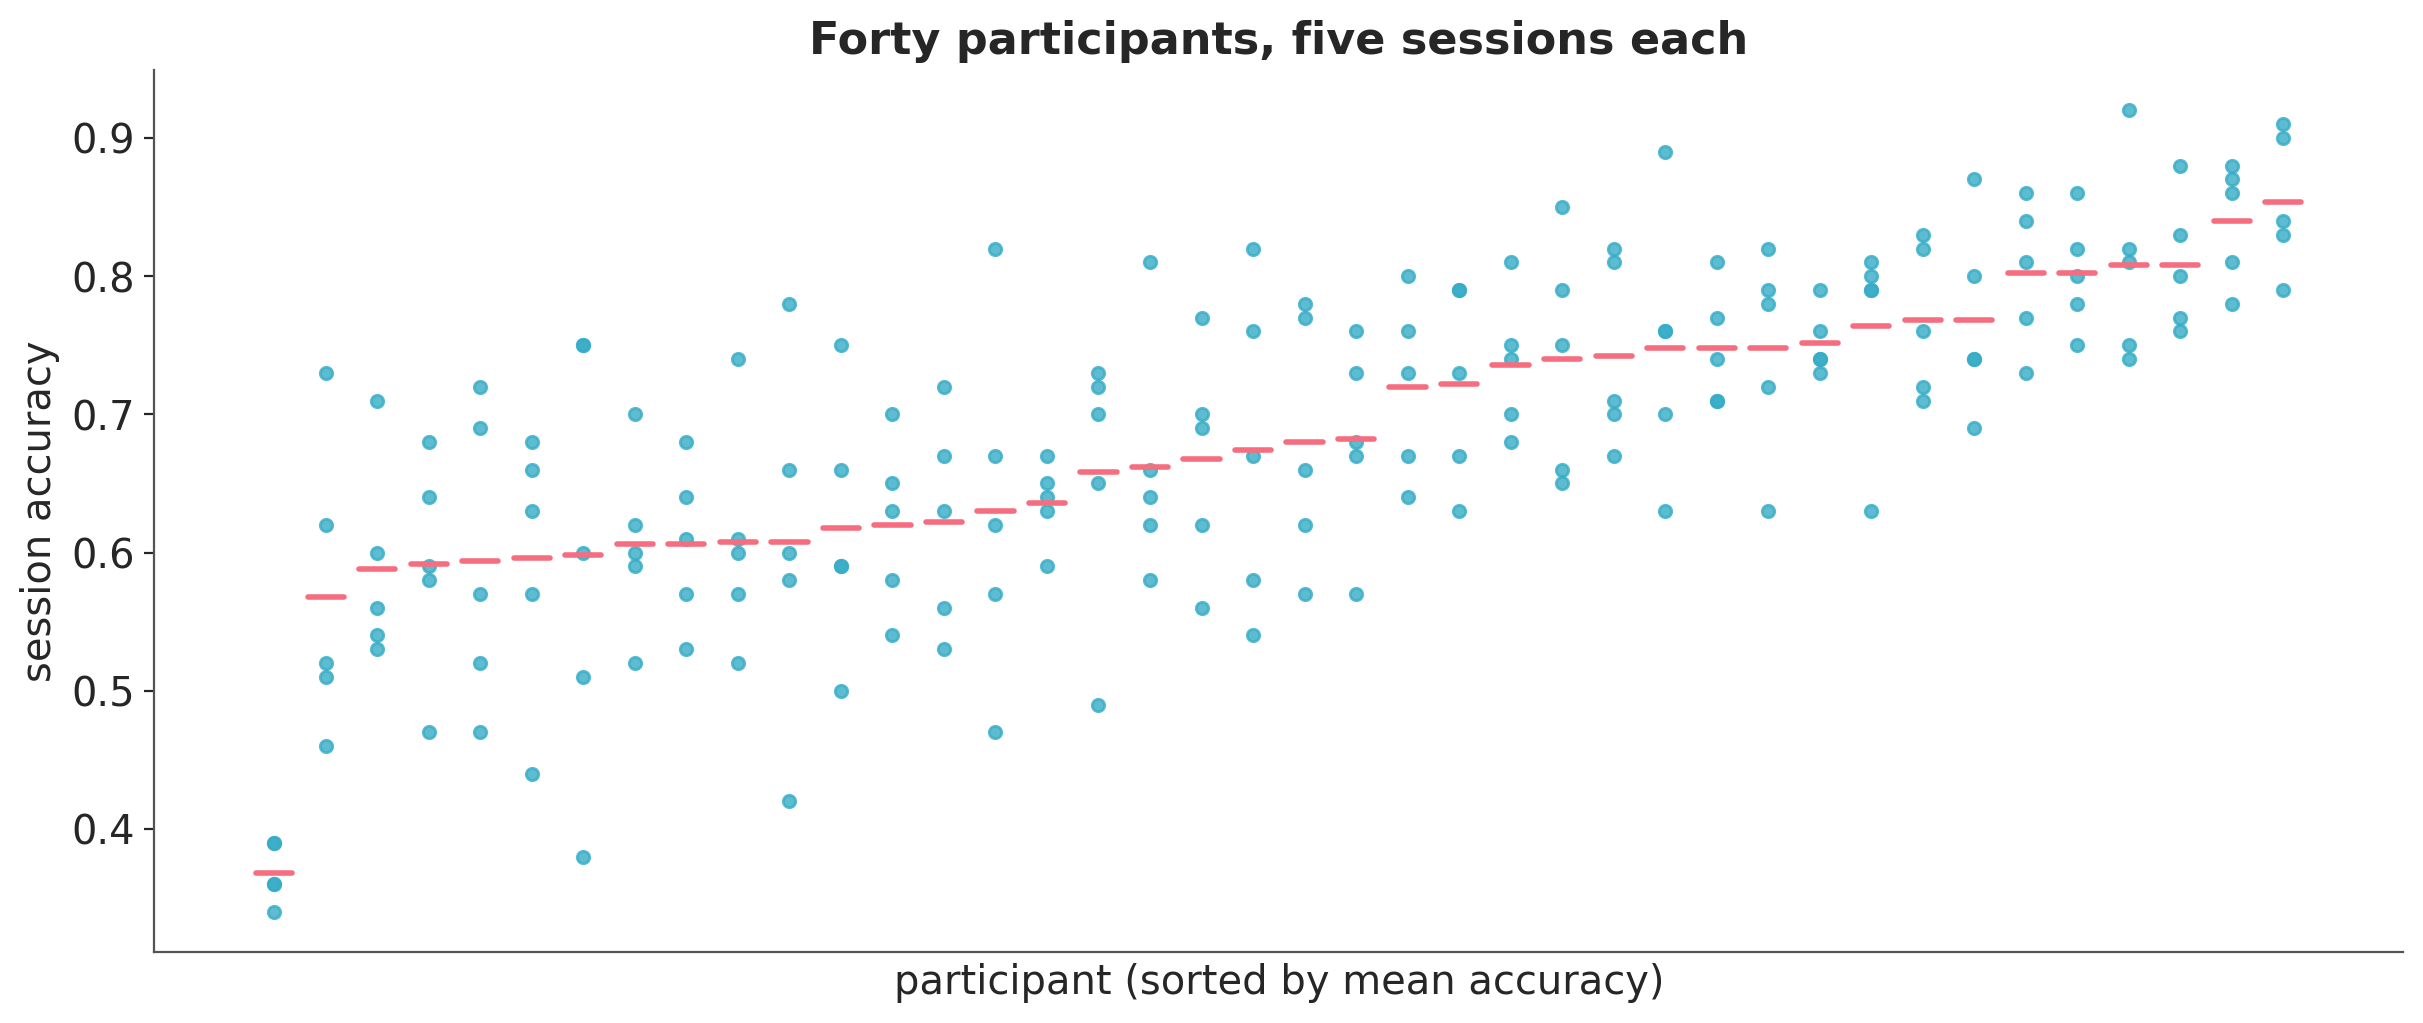

In [ ]:
order = sessions.groupby("participant")["accuracy"].mean().sort_values().index

fig, ax = plt.subplots(figsize=(12, 5))
for rank, pid in enumerate(order):
    acc = sessions.loc[sessions["participant"] == pid, "accuracy"]
    ax.scatter(np.full(len(acc), rank), acc, s=20, alpha=0.8, color="C0")
    ax.plot([rank - 0.35, rank + 0.35], [acc.mean()] * 2, color="C1", lw=2)
ax.set(
    xlabel="participant (sorted by mean accuracy)",
    ylabel="session accuracy",
    xticks=[],
    title="Forty participants, five sessions each",
);

So what is it: story one or story two? Hard to tell by looking at the plot.

Well the good thing is that story 1 makes a clear prediction: across sessions, a participant's accuracy should vary by exactly $\sqrt{p(1-p)/100}$ (binomial variance formula).

That means **we can compare each participant's observed spread to that theoretical variance**. A ratio of 1 means "noise explains it"; larger means "something else is moving":

In [ ]:
# observed session-accuracy variance / what a stable ability would give
def variance_ratio(sessions):
    def ratio(group):
        p = group["n_correct"].sum() / group["n_trials"].sum()
        return (group["n_correct"] / group["n_trials"]).var(ddof=1) / (p * (1 - p) / group["n_trials"]).mean()

    return sessions.groupby(["participant", "condition"]).apply(ratio, include_groups=False)

90% of participants spread more than noise alone would produce


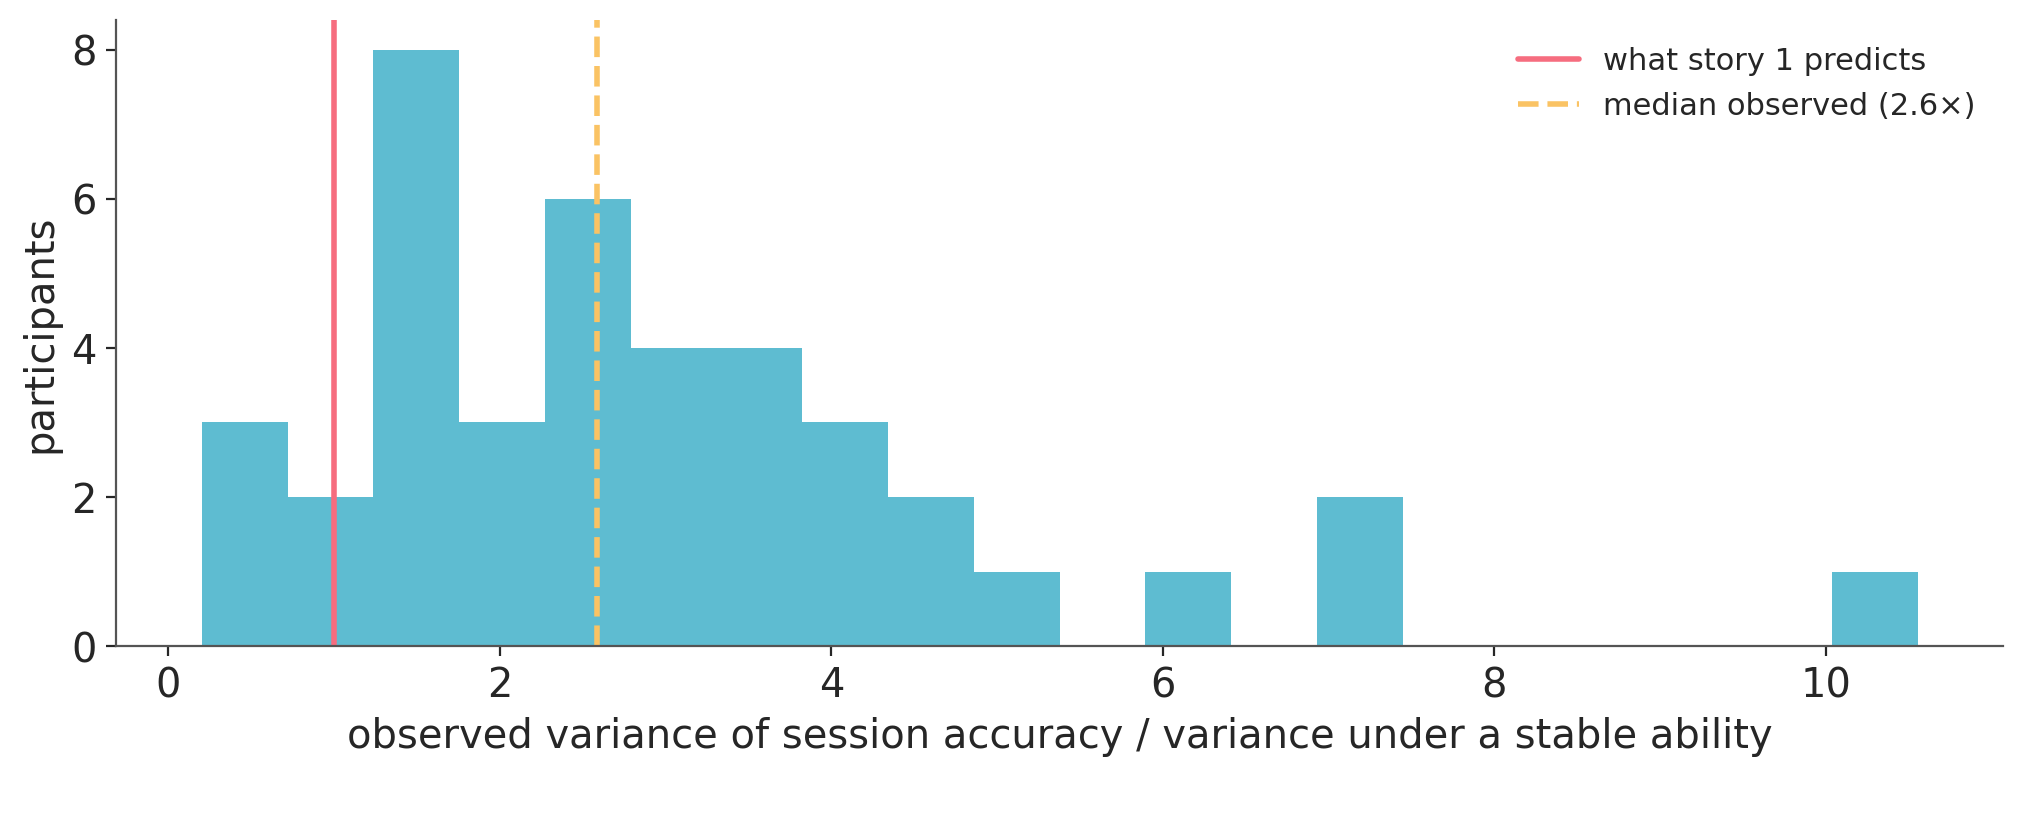

In [ ]:
variance_ratios = variance_ratio(sessions)

print(f"{(variance_ratios > 1).mean():.0%} of participants spread more than noise alone would produce")

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(variance_ratios, bins=20, alpha=0.8)
ax.axvline(1, lw=2, color="C1", label="what story 1 predicts")
ax.axvline(
    variance_ratios.median(), lw=2, ls="--", color="C2", label=f"median observed ({variance_ratios.median():.1f}×)"
)

ax.set(xlabel="observed variance of session accuracy / variance under a stable ability\n", ylabel="participants")
ax.legend();

## 3. Write the models down

In [ ]:
train

,participant,session,condition,n_trials,n_correct
0,1,1,standard,100,77
1,1,2,standard,100,80
2,1,3,standard,100,83
3,1,4,standard,100,88
4,2,1,standard,100,81
...,...,...,...,...,...
155,39,4,standard,100,90
156,40,1,standard,100,68
157,40,2,standard,100,81
158,40,3,standard,100,70


In [ ]:
participants_idx, participants = pd.factorize(train["participant"], sort=True)

COORDS = {"participant": participants, "obs": train.index}

### Story 1: stable ability

In [ ]:
with pm.Model(coords=COORDS) as m1:
    idx = pm.Data("participant_idx", participants_idx, dims="obs")
    n_trials = pm.Data("n_trials", train["n_trials"].to_numpy(), dims="obs")
    n_correct_data = pm.Data("n_correct_data", train["n_correct"].to_numpy(), dims="obs")

    mu = pm.Normal("mu", 0.0, 1.5)  # population-average ability (logit scale)
    sigma_participant = pm.HalfNormal("sigma_participant", 1.0)  # how much participants differ

    theta = pm.Normal("theta", mu, sigma_participant, dims="participant")  # each participant's ability
    p_participant = pm.Deterministic("p_participant", pm.math.invlogit(theta), dims="participant")

    pm.Binomial("n_correct", n=n_trials, p=p_participant[idx], observed=n_correct_data, dims="obs")

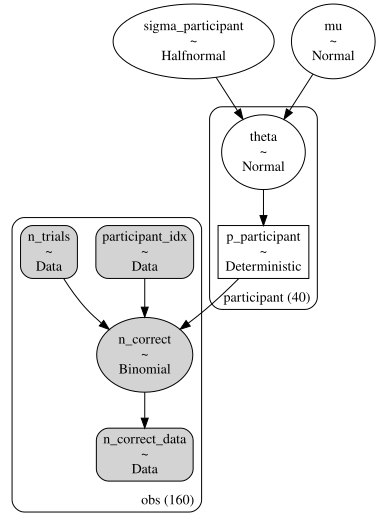

In [ ]:
pm.model_to_graphviz(m1)

### Story 2: each session wobbles around the participant

/usr/local/lib/python3.13/dist-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


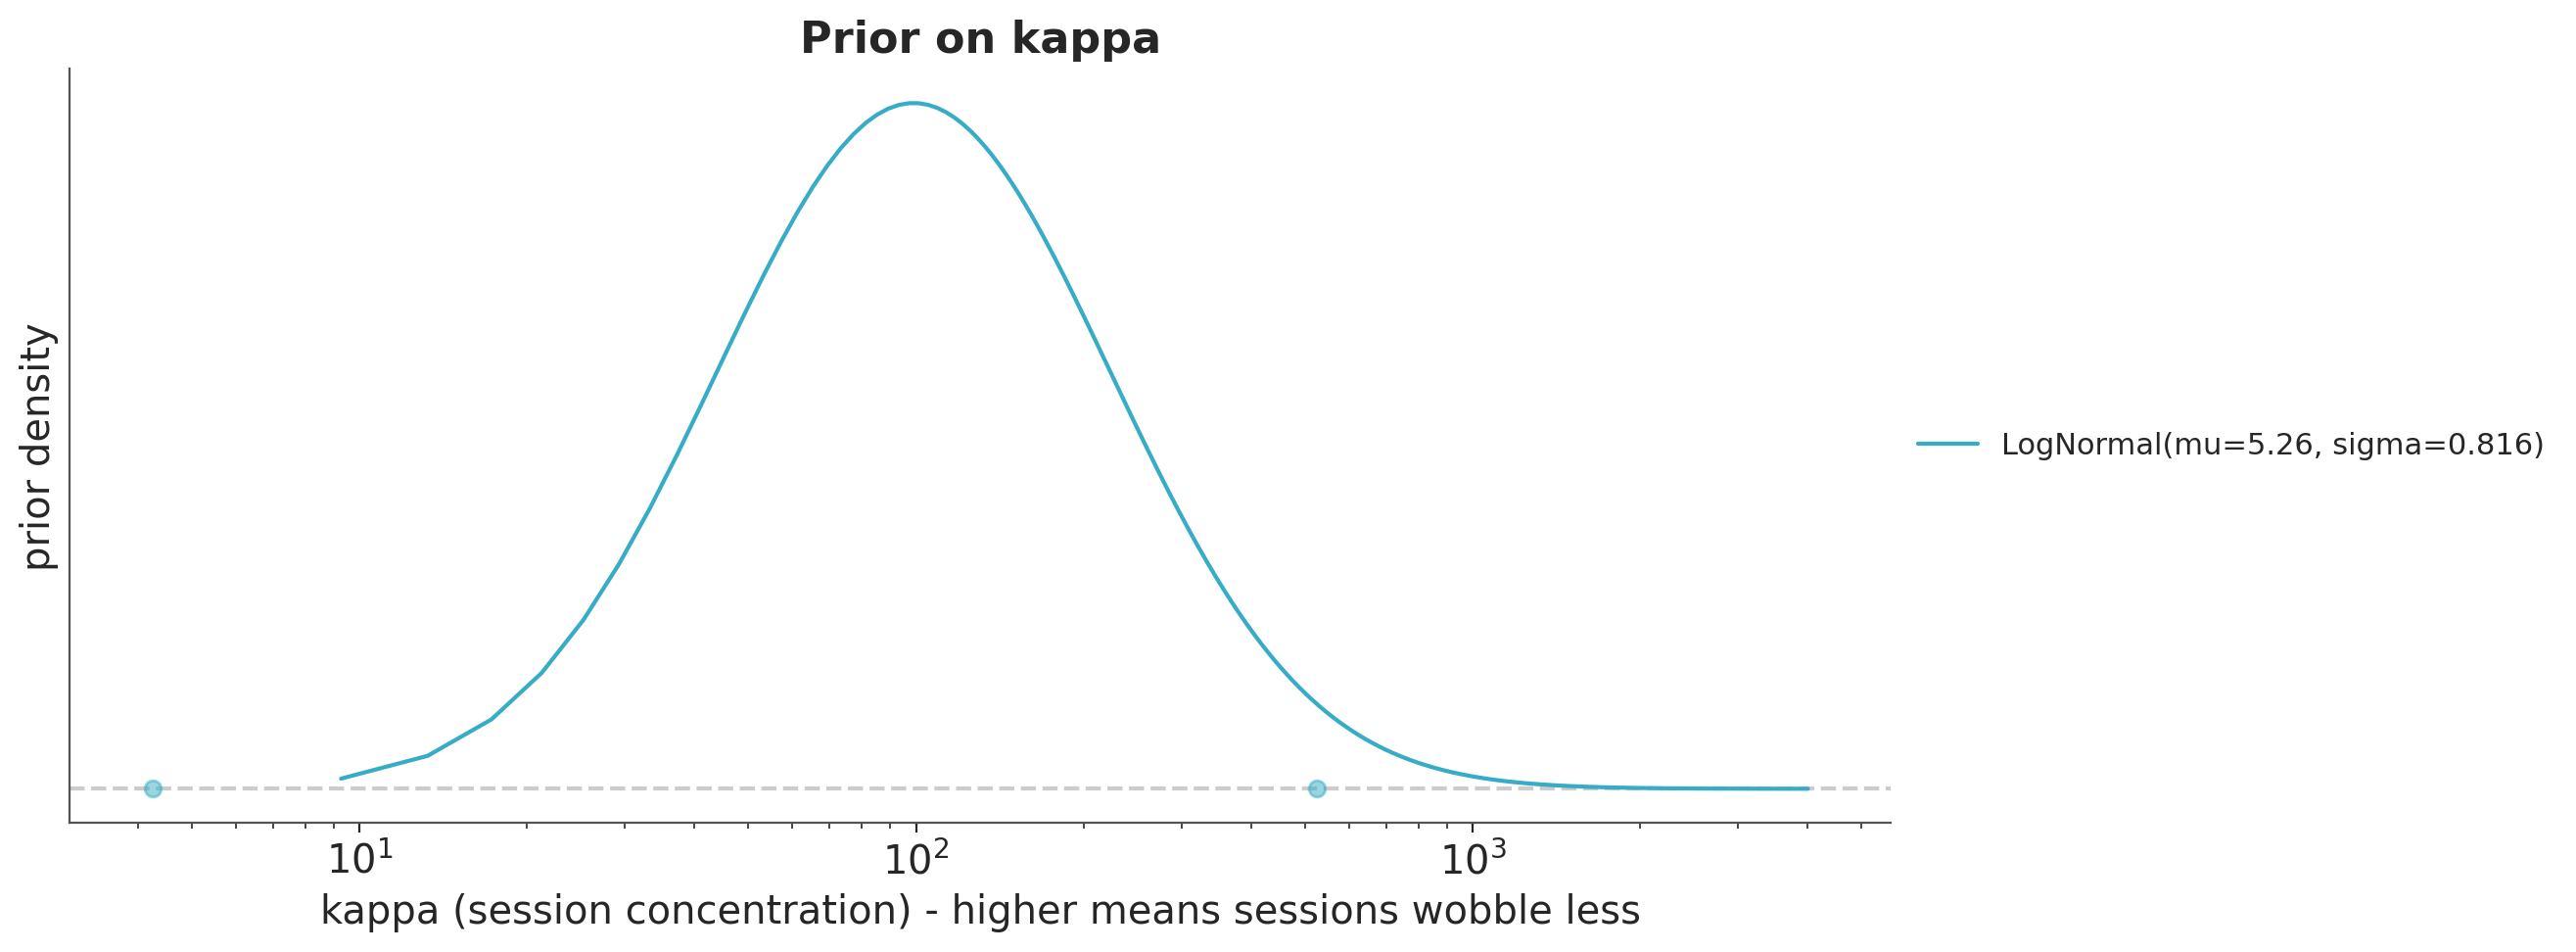

In [ ]:
# session-to-session swings of 2 to 20 accuracy points
kappa_prior, ax = pz.maxent(pz.LogNormal(), lower=kappa_from_sd(0.20), upper=kappa_from_sd(0.02), plot=True)
ax.set(
    xscale="log",  # kappa spans two orders of magnitude; a linear axis squashes the low end
    xlabel="kappa (session concentration) - higher means sessions wobble less",
    ylabel="prior density",
    title="Prior on kappa",
);

In [ ]:
with pm.Model(coords=COORDS) as m2:
    idx = pm.Data("participant_idx", participants_idx, dims="obs")
    n_trials = pm.Data("n_trials", train["n_trials"].to_numpy(), dims="obs")
    n_correct_data = pm.Data("n_correct_data", train["n_correct"].to_numpy(), dims="obs")

    mu = pm.Normal("mu", 0.0, 1.5)
    sigma_participant = pm.HalfNormal("sigma_participant", 1.0)

    theta = pm.Normal("theta", mu, sigma_participant, dims="participant")
    p_participant = pm.Deterministic("p_participant", pm.math.invlogit(theta), dims="participant")

    kappa = kappa_prior.to_pymc("kappa")  # how much sessions move within participants
    p = p_participant[idx]
    pm.BetaBinomial("n_correct", n=n_trials, alpha=p * kappa, beta=(1 - p) * kappa, observed=n_correct_data, dims="obs")

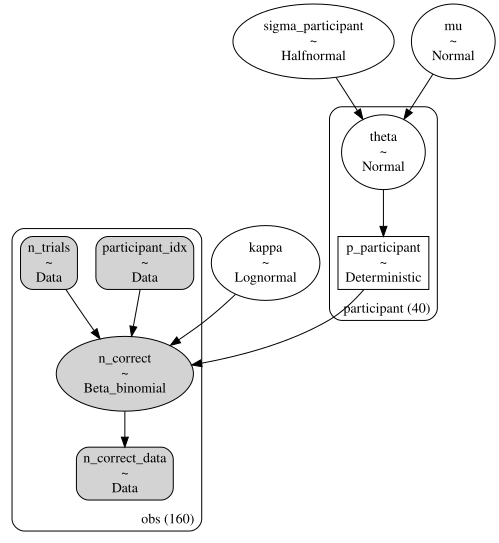

In [ ]:
pm.model_to_graphviz(m2)

## 4. What did we just claim?

The models didn't look at the data yet, but they already have an idea of what they can look like -- through the magic of prior predictive sampling:

In [ ]:
with m1:
    prior_m1 = pm.sample_prior_predictive(draws=500, random_seed=rng)
with m2:
    prior_m2 = pm.sample_prior_predictive(draws=500, random_seed=rng)

In [ ]:
# same Story 1 model with the "uninformative" priors people reach for by default
# only the two prior lines differ

with pm.Model(coords=COORDS) as m1_flat:
    idx = pm.Data("participant_idx", participants_idx, dims="obs")
    n_trials = pm.Data("n_trials", train["n_trials"].to_numpy(), dims="obs")
    n_correct_data = pm.Data("n_correct_data", train["n_correct"].to_numpy(), dims="obs")

    mu = pm.Normal("mu", 0.0, 10.0)  # "flat" on the logit scale
    sigma_participant = pm.HalfNormal("sigma_participant", 10.0)

    theta = pm.Normal("theta", mu, sigma_participant, dims="participant")
    p_participant = pm.Deterministic("p_participant", pm.math.invlogit(theta), dims="participant")

    pm.Binomial("n_correct", n=n_trials, p=p_participant[idx], observed=n_correct_data, dims="obs")

    prior_flat = pm.sample_prior_predictive(draws=500, random_seed=rng)

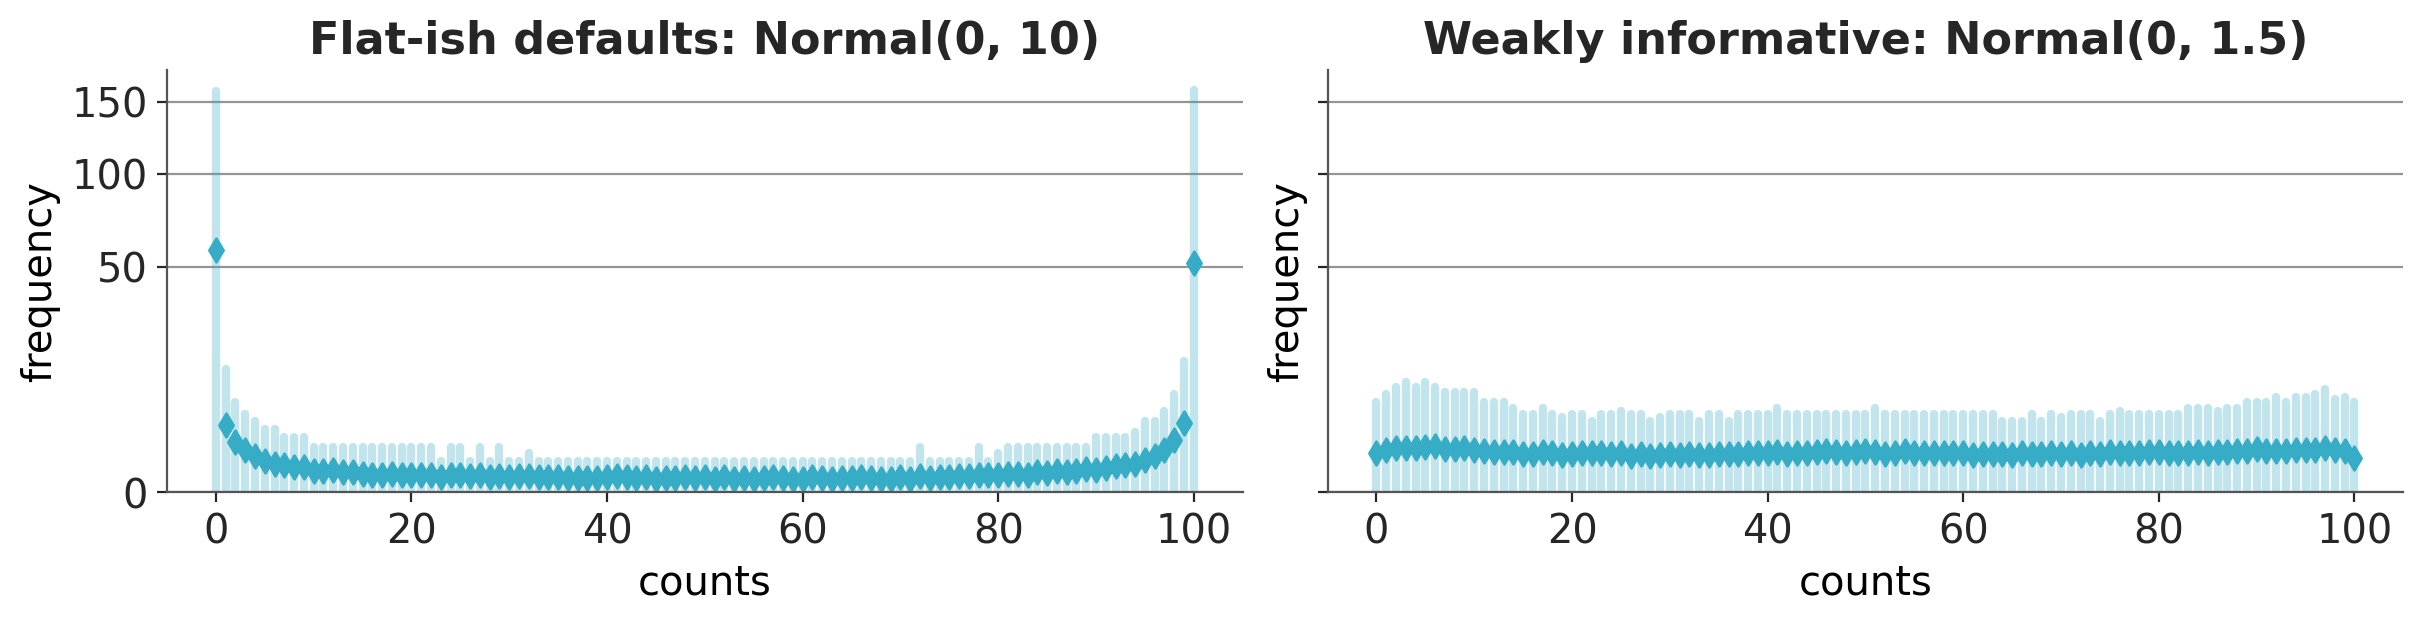

In [ ]:
observed = train["n_correct"].to_numpy()
prior_comparison = az.from_dict(
    {
        "prior_predictive": {
            "Flat-ish defaults: Normal(0, 10)": prior_flat.prior_predictive["n_correct"].values,
            "Weakly informative: Normal(0, 1.5)": prior_m1.prior_predictive["n_correct"].values,
        },
        "observed_data": {"Flat-ish defaults: Normal(0, 10)": observed, "Weakly informative: Normal(0, 1.5)": observed},
    }
)
azp.plot_ppc_rootogram(
    prior_comparison, group="prior_predictive", figure_kwargs={"figsize": (12, 3), "sharex": True, "sharey": True}
);

Turns out **the "flat" prior is not... flat at all**! On the contrary, it says that most participants score either 0% or 100%. Normal(0, 1.5) on the other hand, treats every count as about equally plausible: wide, nothing ruled out, nothing favoured.

Neither prior is "correct", but the weakly informative one is usually better, unless you have more prior information - so **always run prior predictive checks before sampling your models**.


## 5. Sample both, then check convergence

Now we're ready for the real action: sample the posterior (NUTS via nutpie), attach the prior draws, simulate replicated data from the posterior, and compute pointwise log-likelihoods for model comparison.

In [ ]:
def sample(model, prior, **kw):
    with model:
        idata = pm.sample(**sampler_kwargs(**kw))
        idata.update(prior)
        # for group in ("prior", "prior_predictive"):
        #     idata[group] = prior[group]
        pm.sample_posterior_predictive(idata, extend_inferencedata=True, random_seed=rng)
        pm.compute_log_likelihood(idata, extend_inferencedata=True)
    return idata

In [ ]:
idata_m1 = sample(m1, prior_m1)
idata_m2 = sample(m2, prior_m2)

Output()

Output()

Output()

Output()

Then, ArviZ has a very handy function to run the most important post-sampling diagnostics for us:

In [ ]:
print("── Story 1 (binomial) ──")
azs.diagnose(idata_m1)

── Story 1 (binomial) ──
Divergences
No divergent transitions found.

E-BFMI
E-BFMI satisfactory for all chains.

ESS
Effective sample size satisfactory for all parameters.

R-hat
R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


False

In [ ]:
print("\n── Story 2 (beta-binomial) ──")
azs.diagnose(idata_m2)


── Story 2 (beta-binomial) ──
Divergences
No divergent transitions found.

E-BFMI
E-BFMI satisfactory for all chains.

ESS
Effective sample size satisfactory for all parameters.

R-hat
R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


False

No divergences, R-hat at 1.00, plenty of effective samples: the *sampler* did its job. That says nothing yet about whether the *models* did theirs.

## 6. Did the models find the truth we planted?

Remember that we simulated the true parameters, so now, we can check whether the models recovered the true participants' abilities:

In [ ]:
truth_participants = pd.read_csv(DATA_URL + "truth_participants.csv").set_index("participant")
p_true = truth_participants.loc[participants, "p_standard"]
by_ability = p_true.sort_values(ascending=False).index

In [ ]:
recovery = {
    "Story 1 (binomial)": idata_m1.posterior.to_dataset().sel(participant=by_ability),
    "Story 2 (beta-binomial)": idata_m2.posterior.to_dataset().sel(participant=by_ability),
}
truth_marks = p_true[by_ability].rename("p_participant").to_xarray().expand_dims(model=list(recovery))

Story 1 (binomial): 68% of true abilities inside the 90% intervals; mean interval width 0.072
Story 2 (beta-binomial): 95% of true abilities inside the 90% intervals; mean interval width 0.121


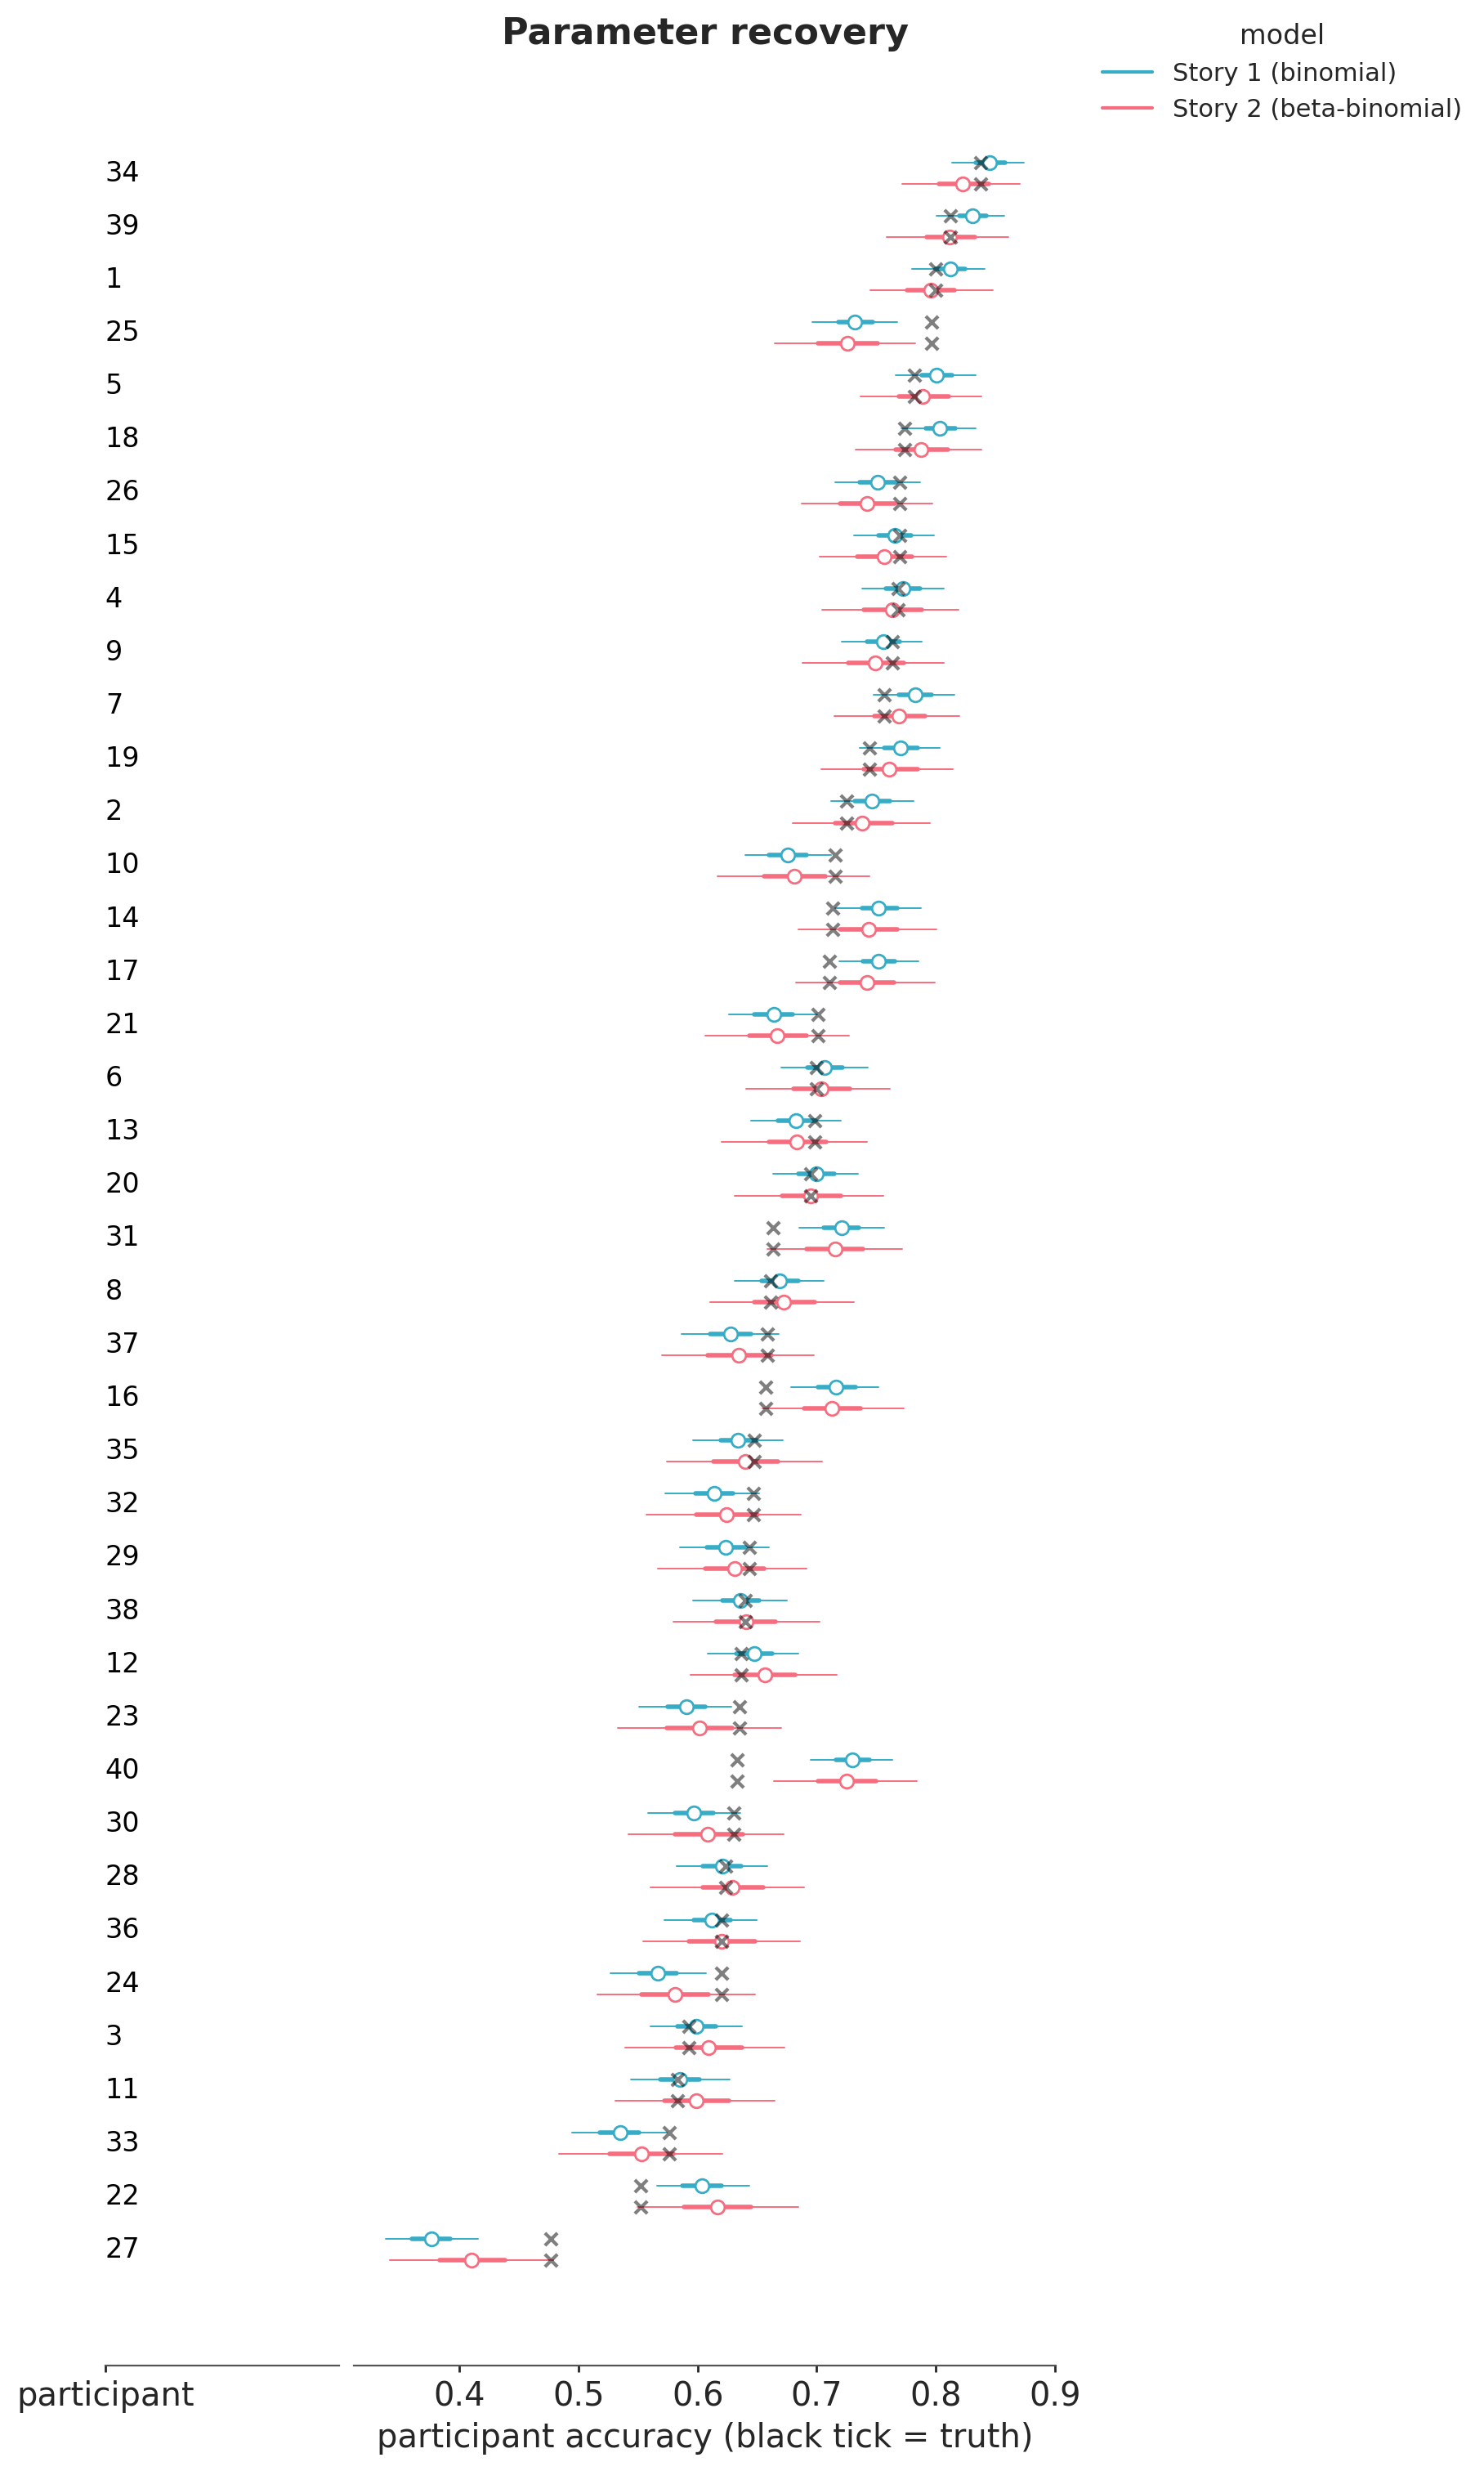

In [ ]:
pc = azp.plot_forest(recovery, var_names="p_participant", ci_probs=(0.5, 0.9), combined=True, labels=["participant"])
pc.map(
    azp.visuals.scatter_x,
    "truth",
    data=truth_marks,
    coords={"column": "forest"},
    ignore_aes={"color"},
    marker="x",
    color="k",
    alpha=0.5,
    size=30,
)
pc.add_legend("model")
pc.viz["plot"].sel(column="forest").item().set(
    xlabel="participant accuracy (black tick = truth)", title="Parameter recovery"
)
pc.viz["figure"].item().set_size_inches(9, 15)

for name, posterior in recovery.items():
    lo, hi = posterior["p_participant"].quantile([0.05, 0.95], dim=("chain", "draw")).values
    inside = (p_true[by_ability] >= lo) & (p_true[by_ability] <= hi)
    print(
        f"{name}: {inside.mean():.0%} of true abilities inside the 90% intervals; mean interval width {np.mean(hi - lo):.3f}"
    )

Story 1's intervals are *narrower* and cover the truth *less often*, meaning the model is over-confident, which is not surprising: model 1 has no place to put between-session variance, contrary to model 2, as we can see below.

true kappa = 42  ->  posterior 90% interval [35, 66]
in accuracy units: sessions wander by 0.056–0.076 (truth 0.070)


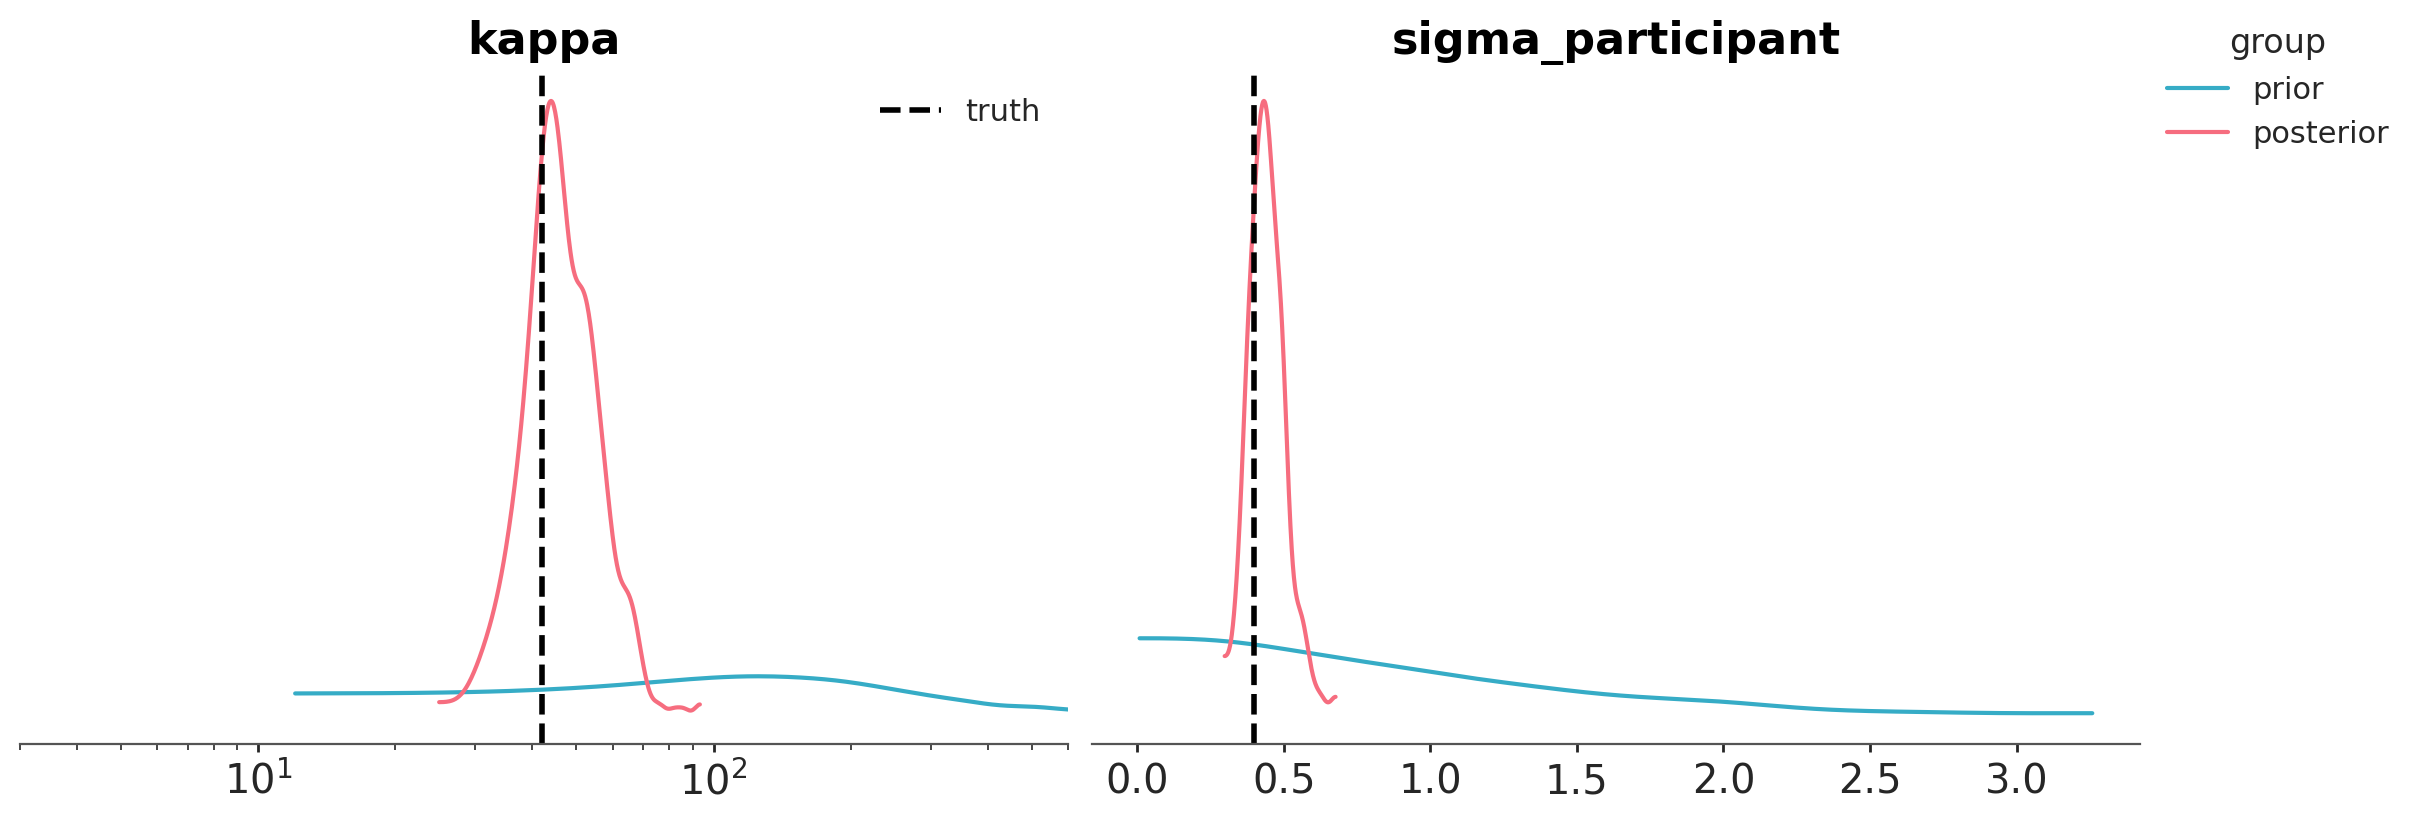

In [ ]:
pc = azp.plot_prior_posterior(idata_m2, var_names=["kappa", "sigma_participant"])

for var, value in [("kappa", truth["kappa"]), ("sigma_participant", truth["sigma_participant"])]:
    ax = pc.viz["plot"][var].item()
    ax.axvline(value, color="k", ls="--", lw=2, label="truth")

kax = pc.viz["plot"]["kappa"].item()
kax.set_xscale("log")  # the prior runs out to ~500; log scale shows the posterior spike on 42
kax.set_xlim(3, 600)

kax.legend()
kax.figure.set_size_inches(12, 4)

k_lo, k_hi = idata_m2.posterior["kappa"].quantile([0.05, 0.95], dim=("chain", "draw")).values
sd_lo, sd_hi = sd_from_kappa(k_hi), sd_from_kappa(k_lo)
print(f"true kappa = {truth['kappa']:.0f}  ->  posterior 90% interval [{k_lo:.0f}, {k_hi:.0f}]")
print(f"in accuracy units: sessions wander by {sd_lo:.3f}–{sd_hi:.3f} (truth {truth['sd_between_sessions']:.3f})")

The posterior on $\kappa$ has moved a long way from the prior (the wide, faint curve) and sits on
the value we planted. Model 2 recovered the between-session variability from forty participants' worth of sessions.

## 7. A model that samples is not a model you should believe (yet)

Both models can now generate *replicated* studies. If a model tells the truth about the data, the data should look like one of its replications - that's the idea behind posterior predictive checks.

The rootograms below compare, for each possible count, how often it appears in the data (black diamonds) against how often the model predicts it (bands):

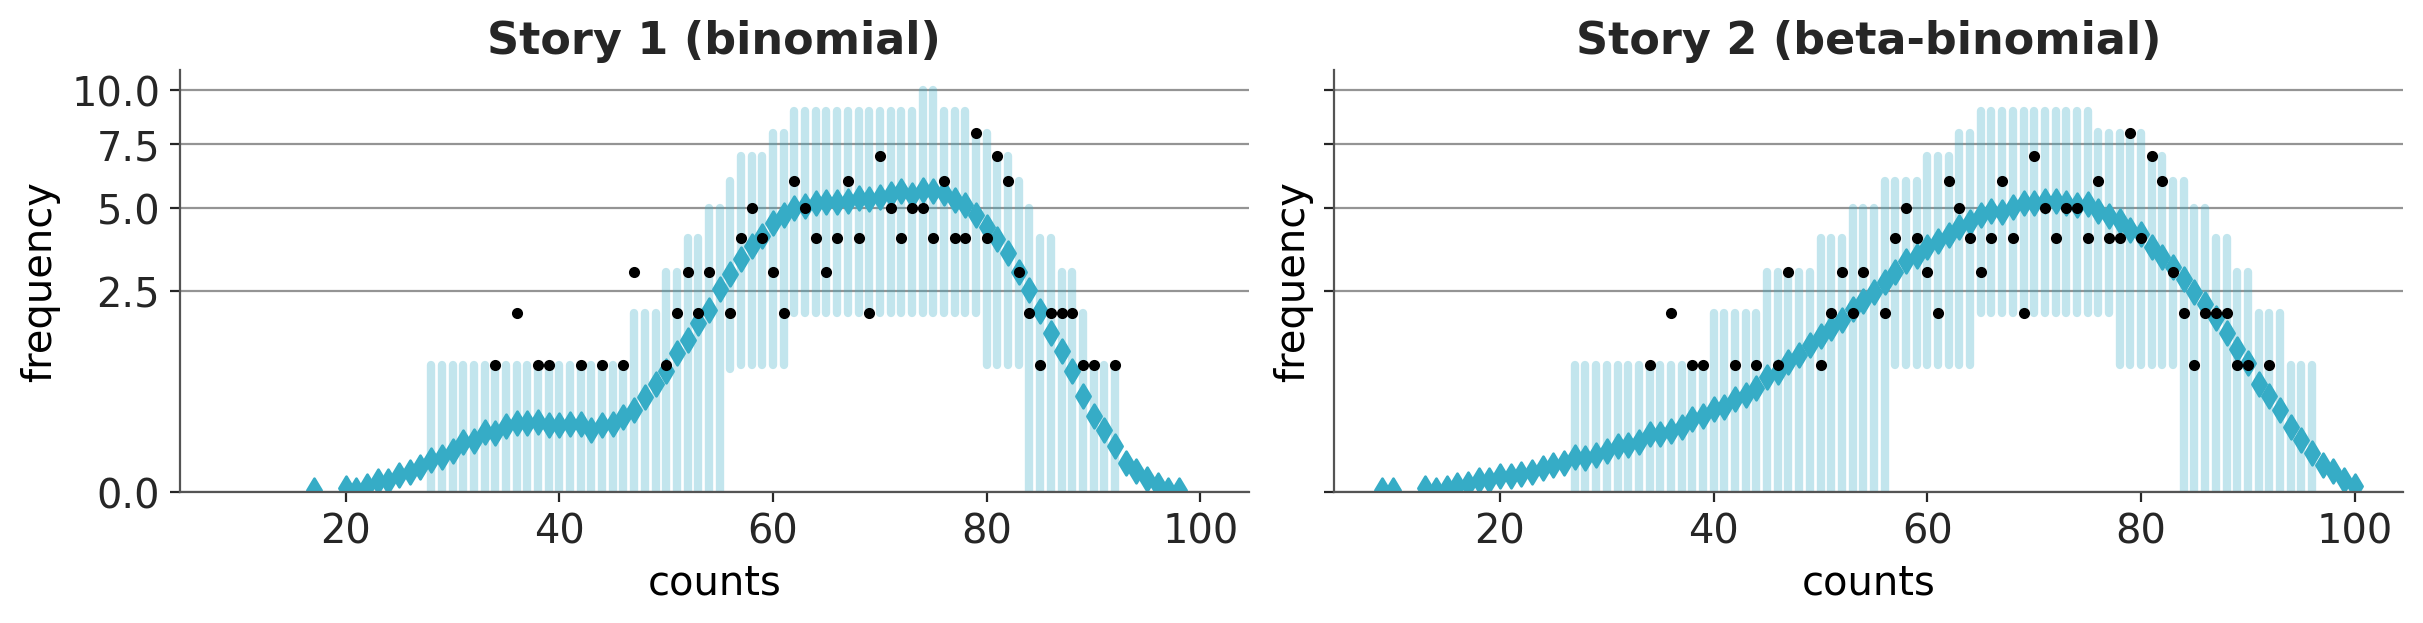

In [ ]:
observed = train["n_correct"].to_numpy()
stories = {"Story 1 (binomial)": idata_m1, "Story 2 (beta-binomial)": idata_m2}
comparison = az.from_dict(
    {
        "posterior": {
            name: idata.posterior["mu"].values for name, idata in stories.items()
        },  # any variable, it only uses it to estimate the relative efficiency for PSIS
        "posterior_predictive": {
            name: idata.posterior_predictive["n_correct"].values for name, idata in stories.items()
        },
        "log_likelihood": {name: idata.log_likelihood["n_correct"].values for name, idata in stories.items()},
        "observed_data": {name: observed for name in stories},
    }
)
azp.plot_ppc_rootogram(comparison, figure_kwargs={"figsize": (12, 3), "sharex": True, "sharey": True});

Model 1's band is too narrow: the data has more very-low and very-high successes than it predicts. Model 2 is better... but not that much: it doesn't fit the data *that* much better, but it's more cautious, resulting in better coverage overall (actually, think about *how* we could improve model 2).

What is **coverage** actually? Coverage asks **"when the model says X%, is it right X% of the time?"**. If we compute that statistic for every interval width at once, we get the plots below.

The x-axis is the interval the model claims (50%, 80%, 90%…); the y-axis is
how far its *actual* coverage falls above or below that claim. That means the curve represents the actual coverage minus claimed coverage: **a model that keeps its promises sits on the flat dashed line at zero; below zero is over-confident; above zero is cautious**.

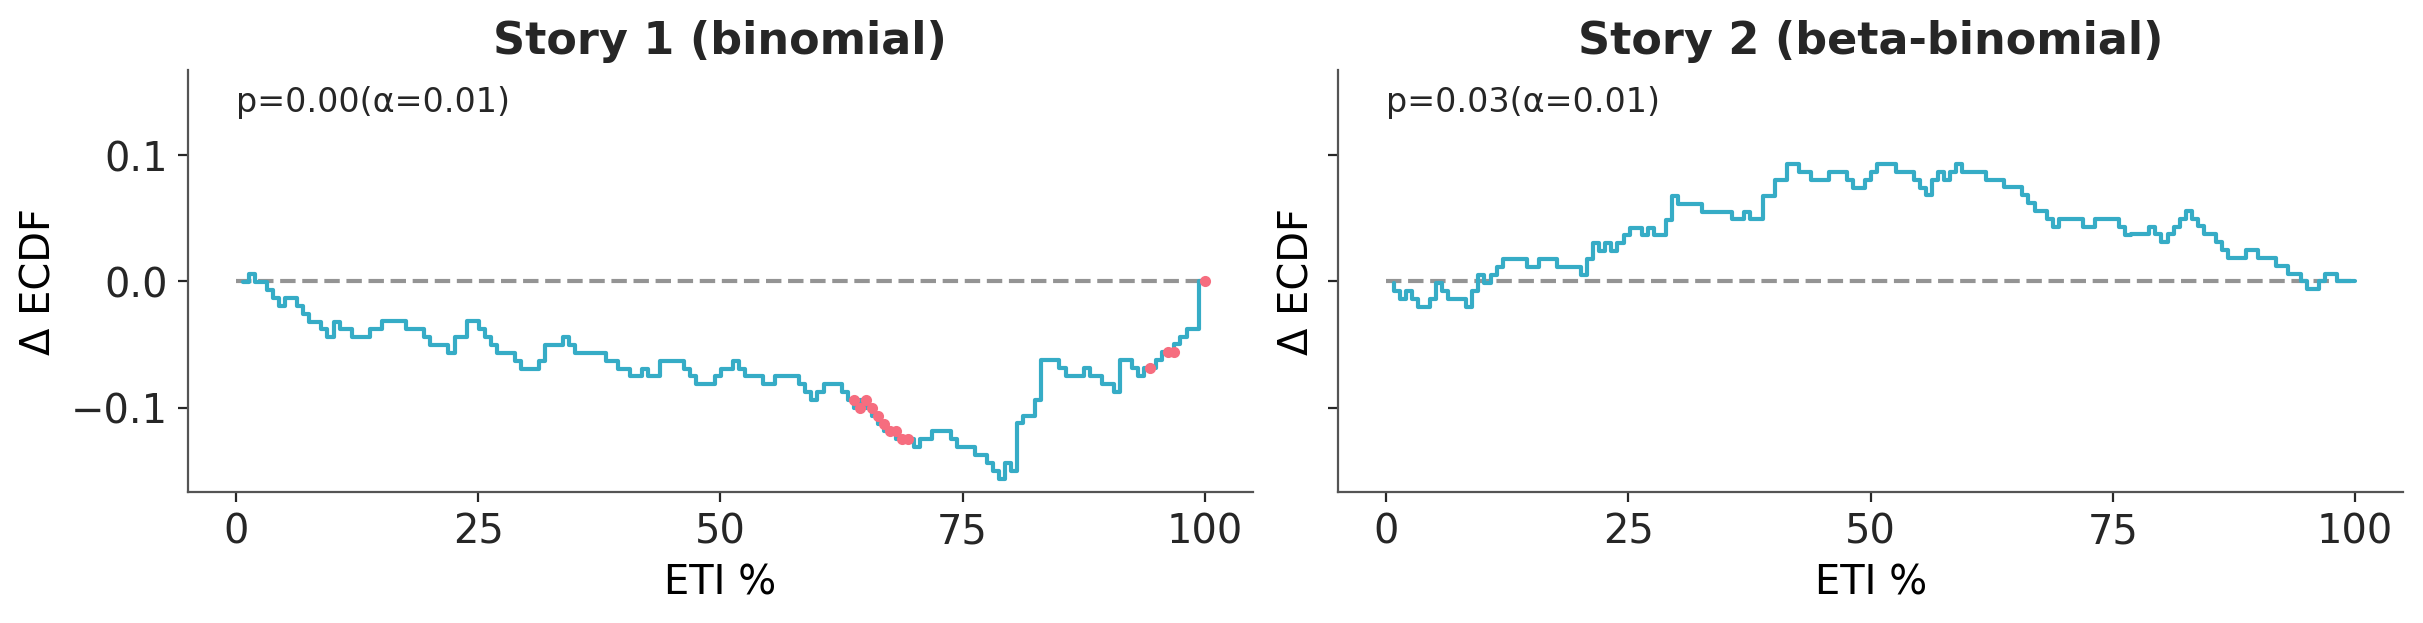

In [ ]:
azp.plot_ppc_pit(comparison, coverage=True, figure_kwargs={"figsize": (12, 3)});

Lots going on here!

- **p-value**: one global **test that the PIT values are uniform, i.e. that the model is calibrated** (default 0.99, hence α = 0.01). Here, uniformity is rejected for Model 1 ($p < α$), i.e the model is not calibrated, but not for Model 2 (although barely, since $p = 0.03$).
- **Red points**: only drawn when $p < α$. They are the observations with the largest Shapley contribution to the rejection, so they say *which* sessions break calibration, not just that calibration is broken - super helpful to a model builder!

Where does that leave us?

- **Model 1**: p = 0.00, curve below zero everywhere, red points near 60% and 90 to 98% widths -> **rejected, in the over-confident direction**.
- **Model 2**: no red points, but p = 0.03 and curve above zero almost everywhere -> **barely *not* rejected, in the cautious direction**.

That last pattern is a classic one of using the data twice (these checks used the same data the models were trained on). Instead, we need to leave each session out in turn; that's **leave-one-out PIT**, which ArviZ also has out of the box!

Before running it, expect Model 1 to worsen (it's already *over*-confident in-sample), and Model 2 to improve (it's cautious in-sample, so has room to "be surprised" by new data coming in). Let's see:

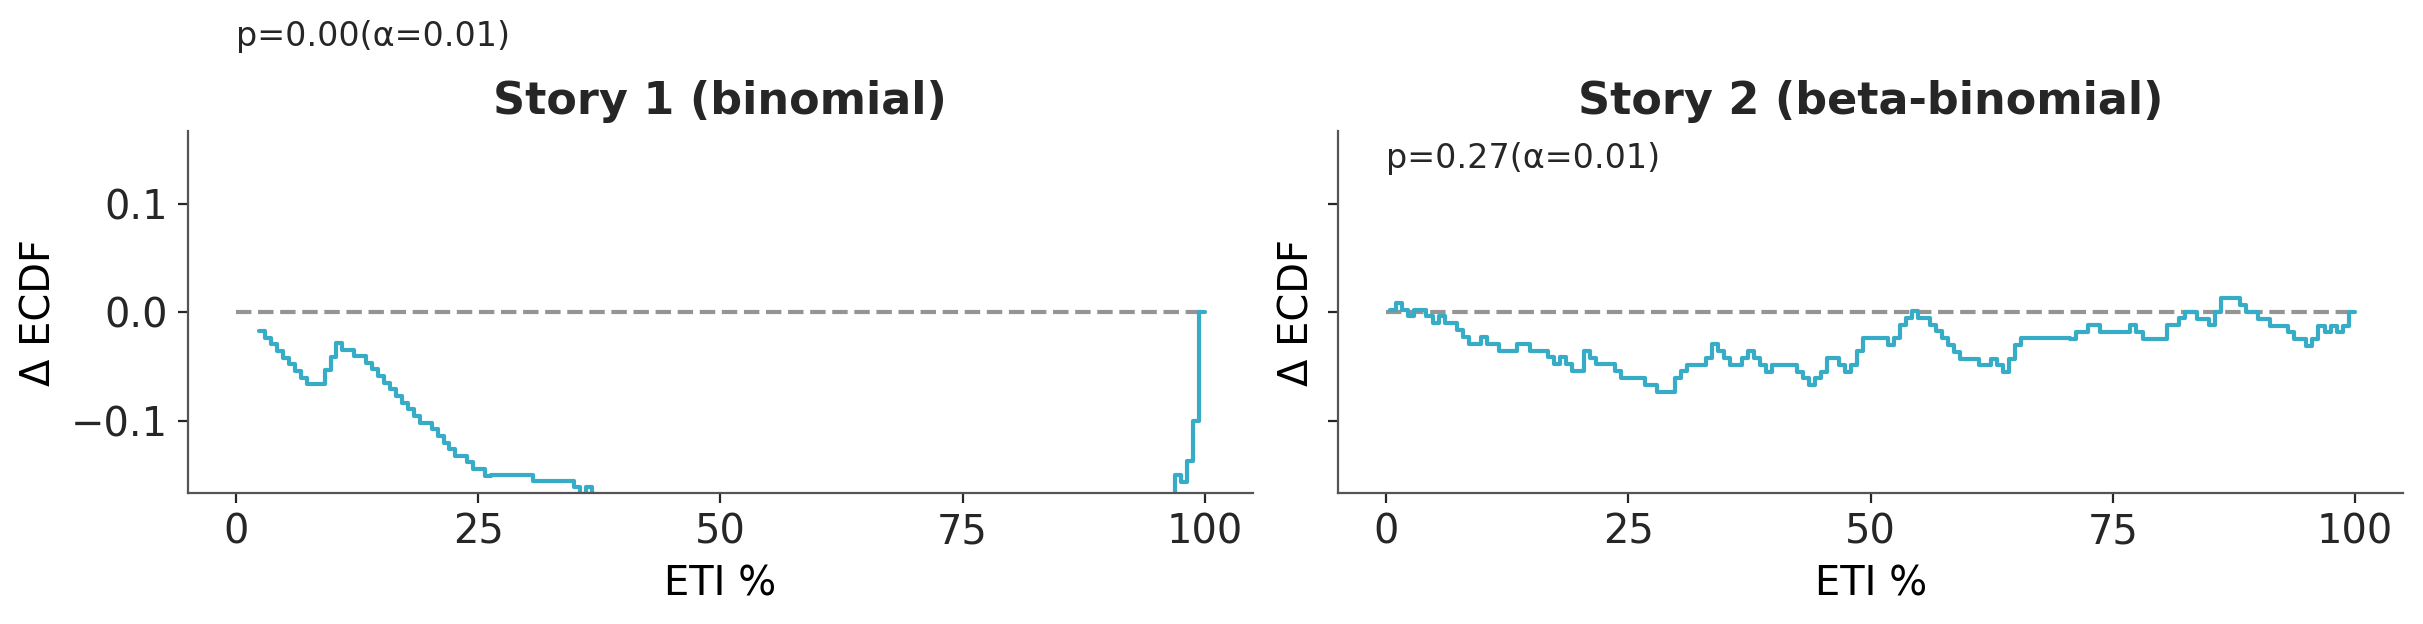

In [ ]:
azp.plot_loo_pit(comparison, coverage=True, figure_kwargs={"figsize": (12, 3)});

Bingo! Story 1 stays broken, with too many observed sessions in the tails of its predictions, while **Story 2 now has no evidence against calibration** (p = 0.27, flatish curve).

## 8. Comparing the models without magic numbers

Another tool in our stats belt is **leave-one-out cross-validation** (LOO-CV, computed by importance sampling from the fitted models), which estimates how well each model would predict a session it has not seen. Bigger ELPD is better and the standard error of the difference tells you how sure to be.

Two important traps I often see students and practitioners fall into:

1. **ELPD is *one* input among several.** The rootogram, the coverage plot and the parameter recovery above all said the same thing *for a reason you can point at* (sessions move). *That* is the evidence. The LOO-CV number is a summary of it, not a replacement.
2. **"Predicts better" ≠ "is true".** Both stories are simplifications; the real question in any study is whether the simplification you chose distorts the answer you care about. No threshold on a difference in ELPD settles that.

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
Story 2 (beta-binomial),0,0.0,0.0,NaN,,1 k̂ > 0.70,34.5,-580.0,8.9,1.0
Story 1 (binomial),1,-80.0,18.0,1.0,,10 k̂ > 0.70,100.5,-660.0,27.0,0.0


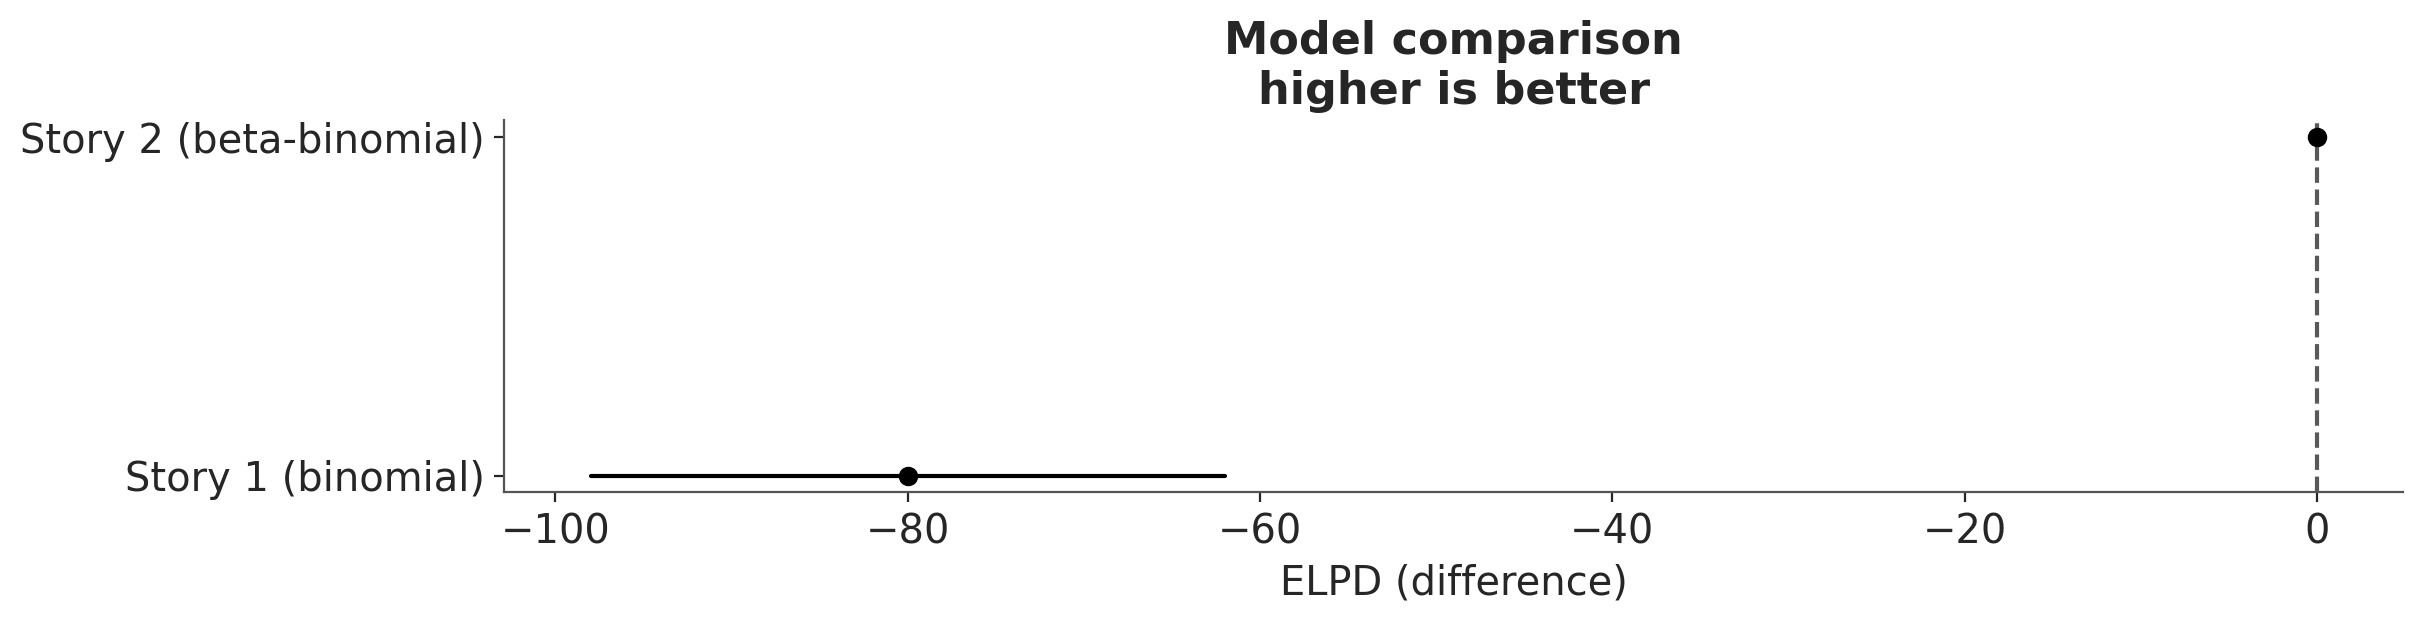

In [ ]:
cmp = azs.compare(stories)
azp.plot_compare(cmp, figure_kwargs={"figsize": (12, 3)})
cmp.round(1)

## 9. Predicting the next session

Remember that we kept session 5 aside as a test set? Now is the time to use it!

In [ ]:
test.head()

,participant,session,condition,n_trials,n_correct
0,1,5,standard,100,76
1,2,5,standard,100,74
2,3,5,standard,100,56
3,4,5,standard,100,63
4,5,5,standard,100,81


In [ ]:
def predict_session_five(model, idata):
    """Sample out-of-sample predictions from model"""
    with model:
        pm.set_data(
            {
                "participant_idx": pd.Categorical(test["participant"].to_numpy(), categories=participants).codes,
                "n_trials": test["n_trials"].to_numpy(),
                "n_correct_data": np.zeros(len(test), dtype=int),
            },  # placeholder, just for shape of vector
            coords={"obs": test.index},
        )
        pred = pm.sample_posterior_predictive(idata, predictions=True, random_seed=rng)

    return pred.predictions["n_correct"] / test["n_trials"].to_numpy()


def by_participant(pred):
    """Label the prediction's rows by participant instead of row number"""
    return pred.rename("accuracy").assign_coords(obs=test["participant"].to_numpy()).rename(obs="participant")

In [ ]:
pred_m1, pred_m2 = predict_session_five(m1, idata_m1), predict_session_five(m2, idata_m2)
predictions = {"Story 1 (binomial)": by_participant(pred_m1), "Story 2 (beta-binomial)": by_participant(pred_m2)}

obs5 = (test["n_correct"] / test["n_trials"]).to_numpy()
session_five = test.assign(accuracy=obs5).set_index("participant")["accuracy"].to_xarray()
shown = session_five.sortby(session_five, ascending=False).participant.values[
    ::3
]  # every third participant, best first

Output()

Output()

Story 1 (binomial): 70% of the 40 session-5 results inside its 90% interval
Story 2 (beta-binomial): 92% of the 40 session-5 results inside its 90% interval


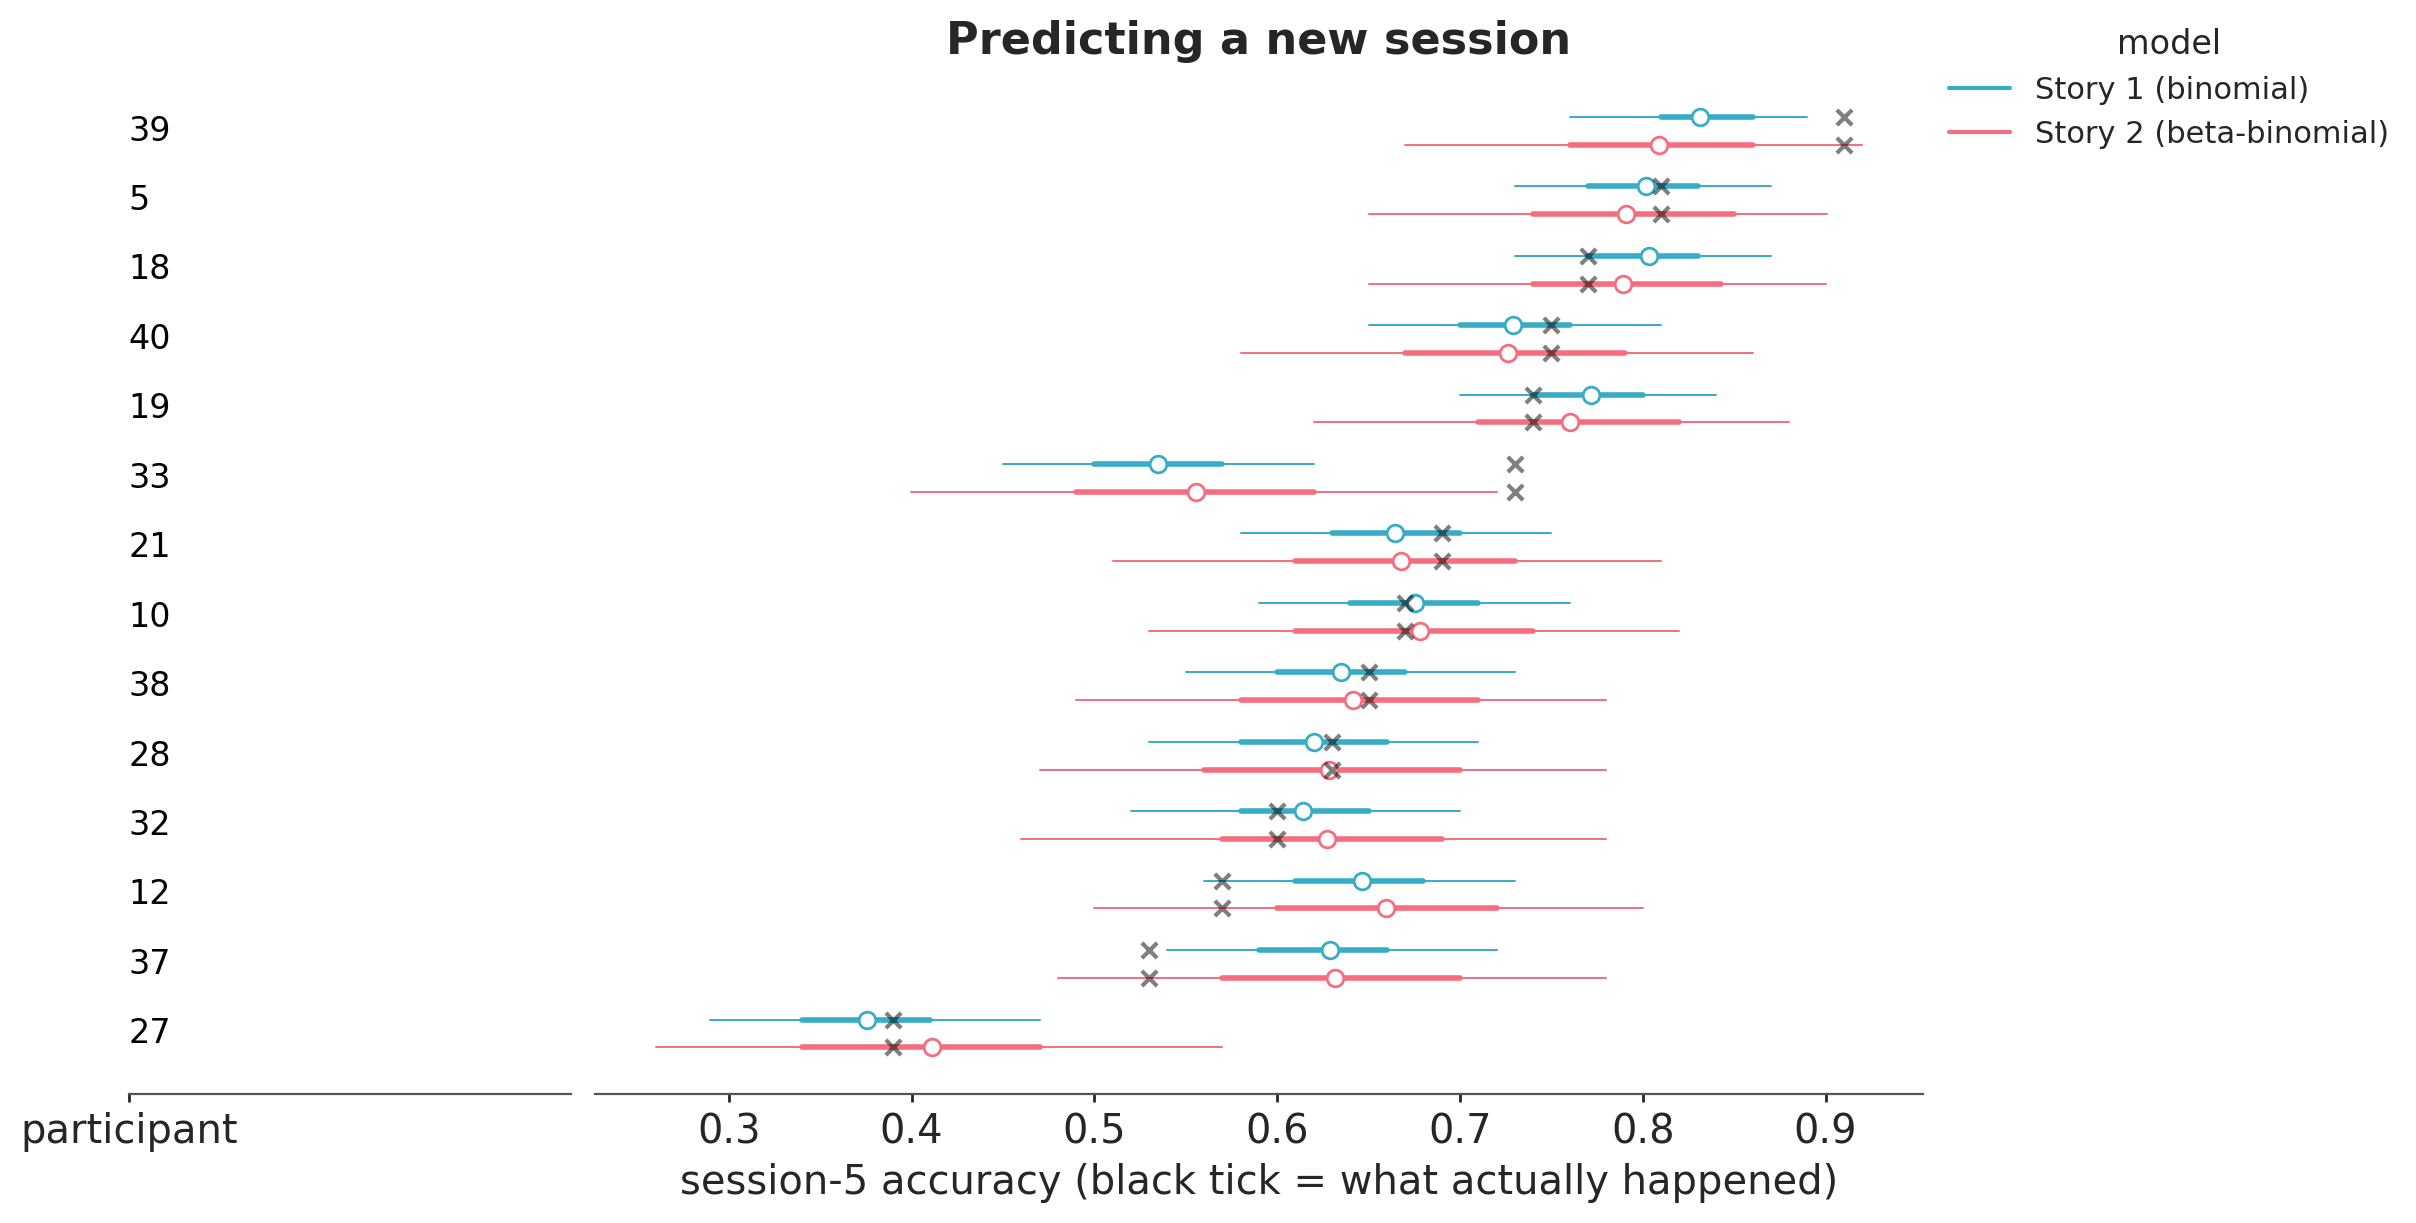

In [ ]:
pc = azp.plot_forest(
    {name: pred.sel(participant=shown).to_dataset() for name, pred in predictions.items()},
    ci_probs=(0.5, 0.9),
    combined=True,
    labels=["participant"],
    figure_kwargs={"figsize": (12, 6)},
)
pc.map(
    azp.visuals.scatter_x,
    "observed",
    data=session_five.sel(participant=shown).expand_dims(model=list(predictions)),
    coords={"column": "forest"},
    ignore_aes={"color"},
    marker="x",
    color="k",
    alpha=0.5,
    size=30,
)
pc.add_legend("model")
pc.viz["plot"].sel(column="forest").item().set(
    xlabel="session-5 accuracy (black tick = what actually happened)", title="Predicting a new session"
)

for name, pred in predictions.items():
    interval = azs.eti(pred, prob=0.9)
    inside = (session_five >= interval.sel(ci_bound="lower")) & (session_five <= interval.sel(ci_bound="upper"))
    print(f"{name}: {inside.mean().item():.0%} of the 40 session-5 results inside its 90% interval")

Same lesson, now out of sample: story 1's intervals are tighter *and* miss more often, which is worse than story 2's wider intervals.

## 10. Watching a session estimate update, trial by trial

Now, something important about me: I *love* chocolate! So, naturally, I left an Easter egg for you in model 2... Did you spot it?

Ok I'll tell you: **the Beta step is *conjugate* to the Binomial trials**, so a session's accuracy can be updated after every single trial, with no MCMC sampler. Let me walk you through it:

**Before a session starts, model 2 already has a prior for that session's accuracy**:
$$
p_{is} \sim \mathrm{Beta}(\alpha_0, \beta_0) \, with \, \alpha_0 = p_i\kappa \, and \, \beta_0 = (1-p_i)\kappa
$$

The Beta density is $p^{\alpha_0-1}(1-p)^{\beta_0-1}$; $N$ trials with $w$ correct contribute a likelihood $p^{w}(1-p)^{N-w}$. Multiply them, and you get the posterior (the exponents add):

$$p^{(\alpha_0+w)-1}\,(1-p)^{(\beta_0+N-w)-1}$$

Notice something?? **That's a Beta again!** $\mathrm{Beta}(\alpha_0+w,\ \beta_0+N-w)$ to be precise. In other words, each correct trial adds 1 to $\alpha_0$, each miss adds 1 to $\beta_0$.

$\alpha_0$ and $\beta_0$ are basically pseudo-counts, and you can see how the participant's history influences the posterior and how $\kappa$ scales the importance of the trials (smaller $\kappa$ means less concentration, which means previous history is less important).

That's why you'll see **the live estimate below start on the participant's mean and bend toward the session's data as trials accumulate**.

Two small things, just to be complete:

- In the code below, **we compute $\alpha_0$ and $\beta_0$ with the posterior means of $p_i$ and $\kappa$**, so the band ignores their uncertainty. Fine for seeing the mechanism, but keep in mind the actual uncertainty is bigger.

- **Why not do that with model 1?** Because it has no *session-level* $p_{is}$, only $p_i$ with a logit-normal prior, which is not conjugate, so updating it means re-running the sampler.


In [ ]:
post = idata_m2.posterior
i = np.searchsorted(participants, ONE)
alpha0 = float((post["p_participant"].isel(participant=i) * post["kappa"]).mean())
beta0 = float(((1 - post["p_participant"].isel(participant=i)) * post["kappa"]).mean())

In [ ]:
seq = trials_all.query("participant == @ONE and condition == 'standard' and session == 5")["correct"].to_numpy()
N = np.arange(1, len(seq) + 1)
w = np.cumsum(seq)
a_post, b_post = alpha0 + w, beta0 + N - w
mean = a_post / (a_post + b_post)
lo, hi = stats.beta.ppf([[0.05], [0.95]], a_post, b_post)

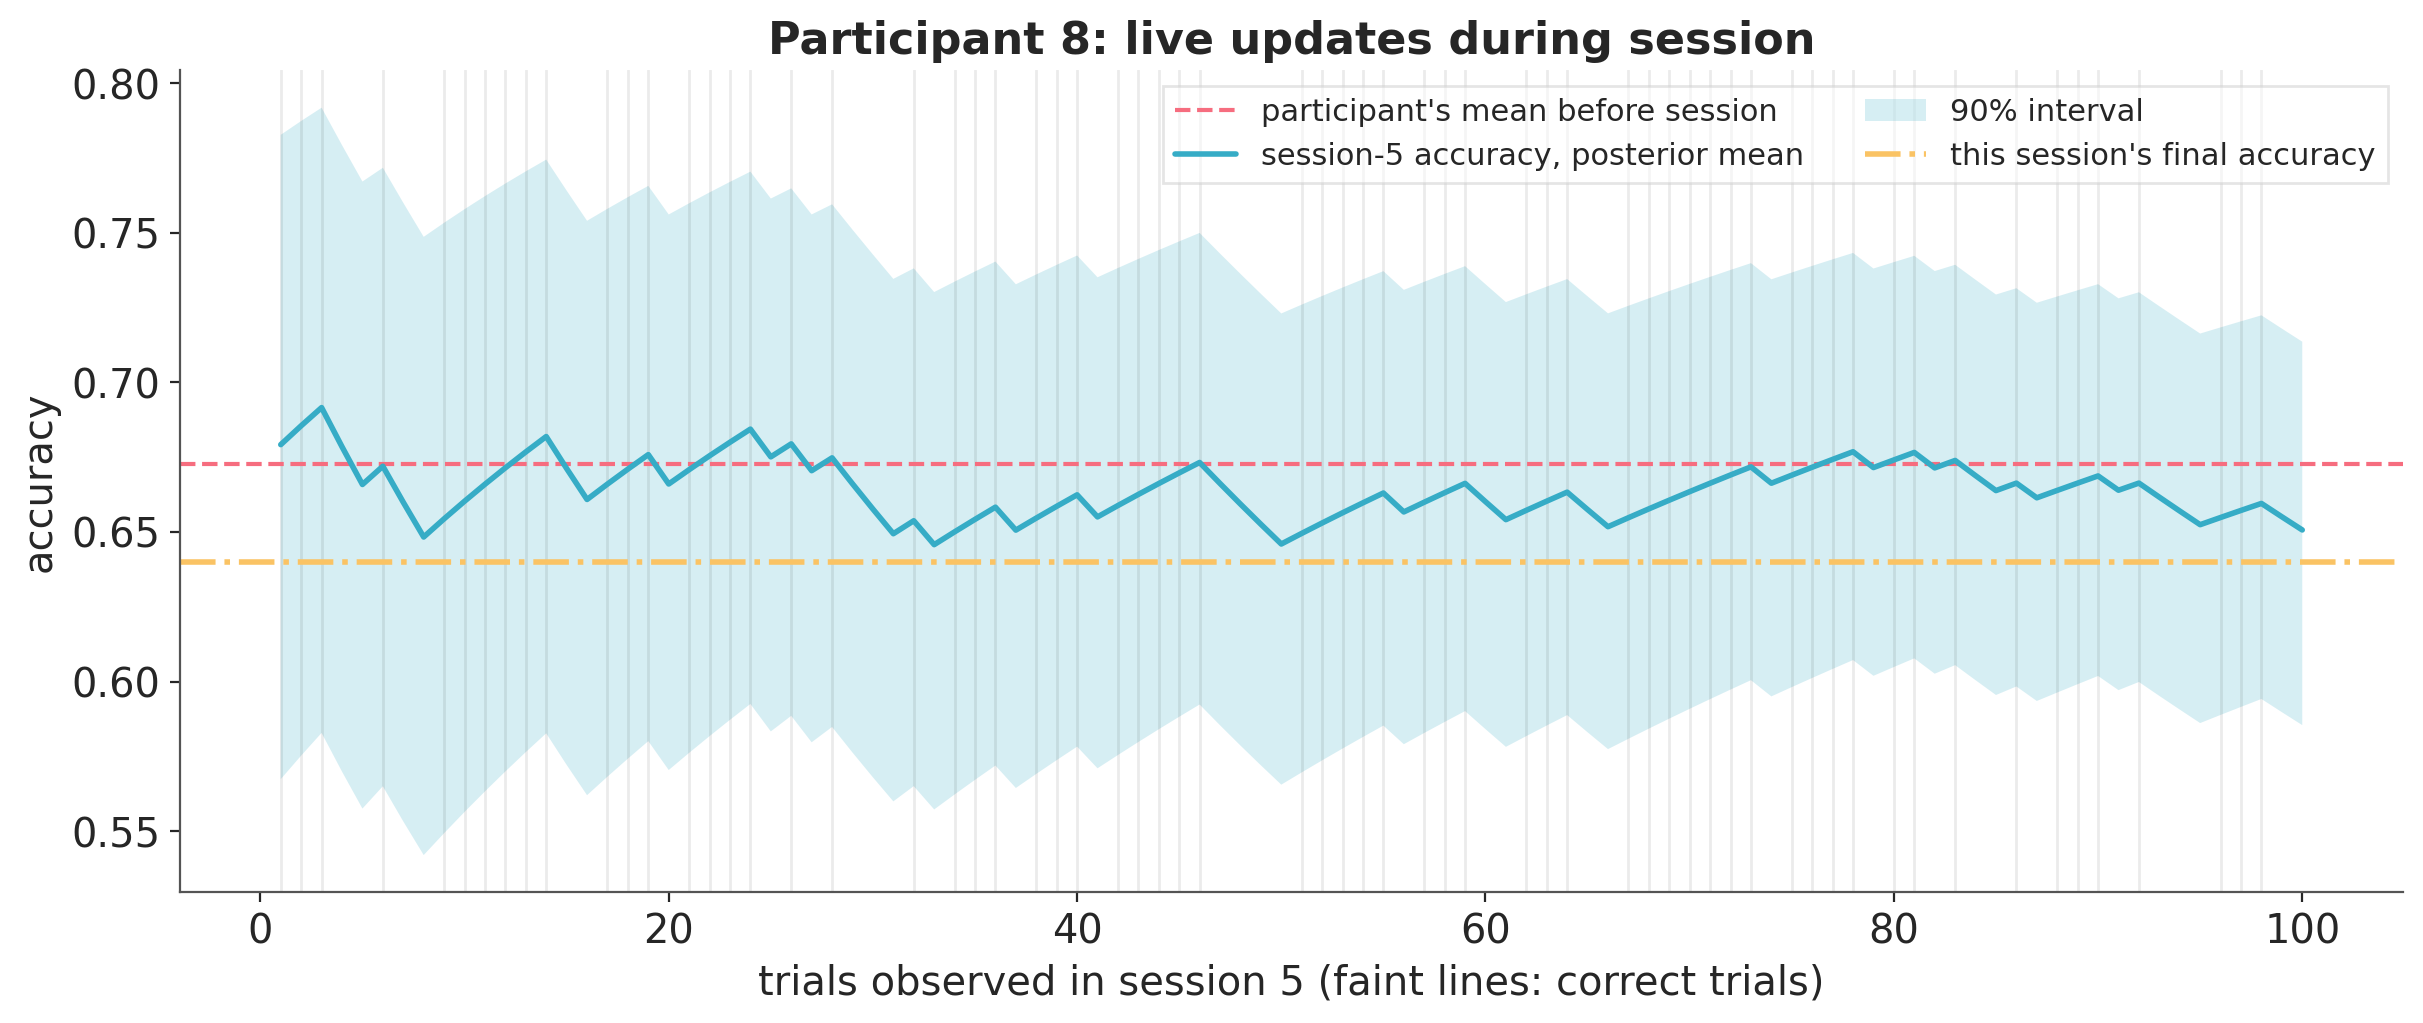

In [ ]:
_, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

for t in N[seq == 1]:
    ax.axvline(t, color="k", alpha=0.08, lw=1)

ax.axhline(alpha0 / (alpha0 + beta0), ls="--", color="C1", label="participant's mean before session")
ax.plot(N, mean, lw=2, label="session-5 accuracy, posterior mean")
ax.fill_between(N, lo, hi, alpha=0.2, label="90% interval")
ax.axhline(
    obs5[test["participant"].to_numpy() == ONE][0], ls="-.", lw=2, color="C2", label="this session's final accuracy"
)

ax.set(
    xlabel="trials observed in session 5 (faint lines: correct trials)",
    ylabel="accuracy",
    title=f"Participant {ONE}: live updates during session",
)
ax.legend(ncol=2, frameon=True);

## 11. Playground: change the world, re-sample, see what breaks

Everything so far used one dataset, but we have a simulator at the beginning of this notebook, so you can make a different
world and watch the models react!

`sample_both` re-samples both models; `report` draws the three checks
that matter: recovery of $\kappa$, coverage, ELPD.

Three experiments I suggest you try (edit the numbers in the last cell and re-run it):

1. **`kappa=1e6`**: sessions don't move at all. Model 2 should collapse into model 1: coverage fine for both, ELPD a wash.
2. **`n_trials=10`**: ten trials per session. Can either model tell the stories apart now, with so little data?
3. **`n_sessions=2`**: two sessions per participant instead of four. Watch the $\kappa$ posterior barely leave its prior.

In [ ]:
def sample_both(sessions_df, draws=400, tune=400):
    """Re-sample both models on a new sessions table: same models (m1, m2), new data. Returns (idata_1, idata_2)."""

    new_data = {
        "participant_idx": pd.factorize(sessions_df["participant"], sort=True)[0],
        "n_trials": sessions_df["n_trials"].to_numpy(),
        "n_correct_data": sessions_df["n_correct"].to_numpy(),
    }

    posteriors = []
    for model in (m1, m2):
        with model:
            pm.set_data(new_data, coords={"obs": sessions_df.index})
            prior = pm.sample_prior_predictive(draws=200, random_seed=rng)
        posteriors.append(sample(model, prior, draws=draws, tune=tune))

    return tuple(posteriors)


def report(idata_1, idata_2, sessions_df, kappa_true):
    """The three checks that matter: recovery of kappa, coverage, ELPD."""

    stories = {"Story 1 (binomial)": idata_1, "Story 2 (beta-binomial)": idata_2}
    observed = sessions_df["n_correct"].to_numpy()
    comparison = az.from_dict(
        {
            "posterior": {
                name: idata.posterior["mu"].values for name, idata in stories.items()
            },  # any variable, it only uses it to estimate the relative efficiency for PSIS
            "posterior_predictive": {
                name: idata.posterior_predictive["n_correct"].values for name, idata in stories.items()
            },
            "log_likelihood": {name: idata.log_likelihood["n_correct"].values for name, idata in stories.items()},
            "observed_data": {name: observed for name in stories},
        }
    )

    pc = azp.plot_prior_posterior(idata_2, var_names=["kappa"], figure_kwargs={"figsize": (12, 3)})
    azp.add_lines(pc, kappa_true, color="k", linestyle="--")
    pc.viz["plot"]["kappa"].item().set(xscale="log", title=f"kappa: prior, posterior, truth ({kappa_true:g}, dashed)")

    azp.plot_loo_pit(comparison, coverage=True, figure_kwargs={"figsize": (12, 3)})
    azp.plot_compare(azs.compare(stories), figure_kwargs={"figsize": (12, 3)})

    return

Output()

Output()

Output()

Output()

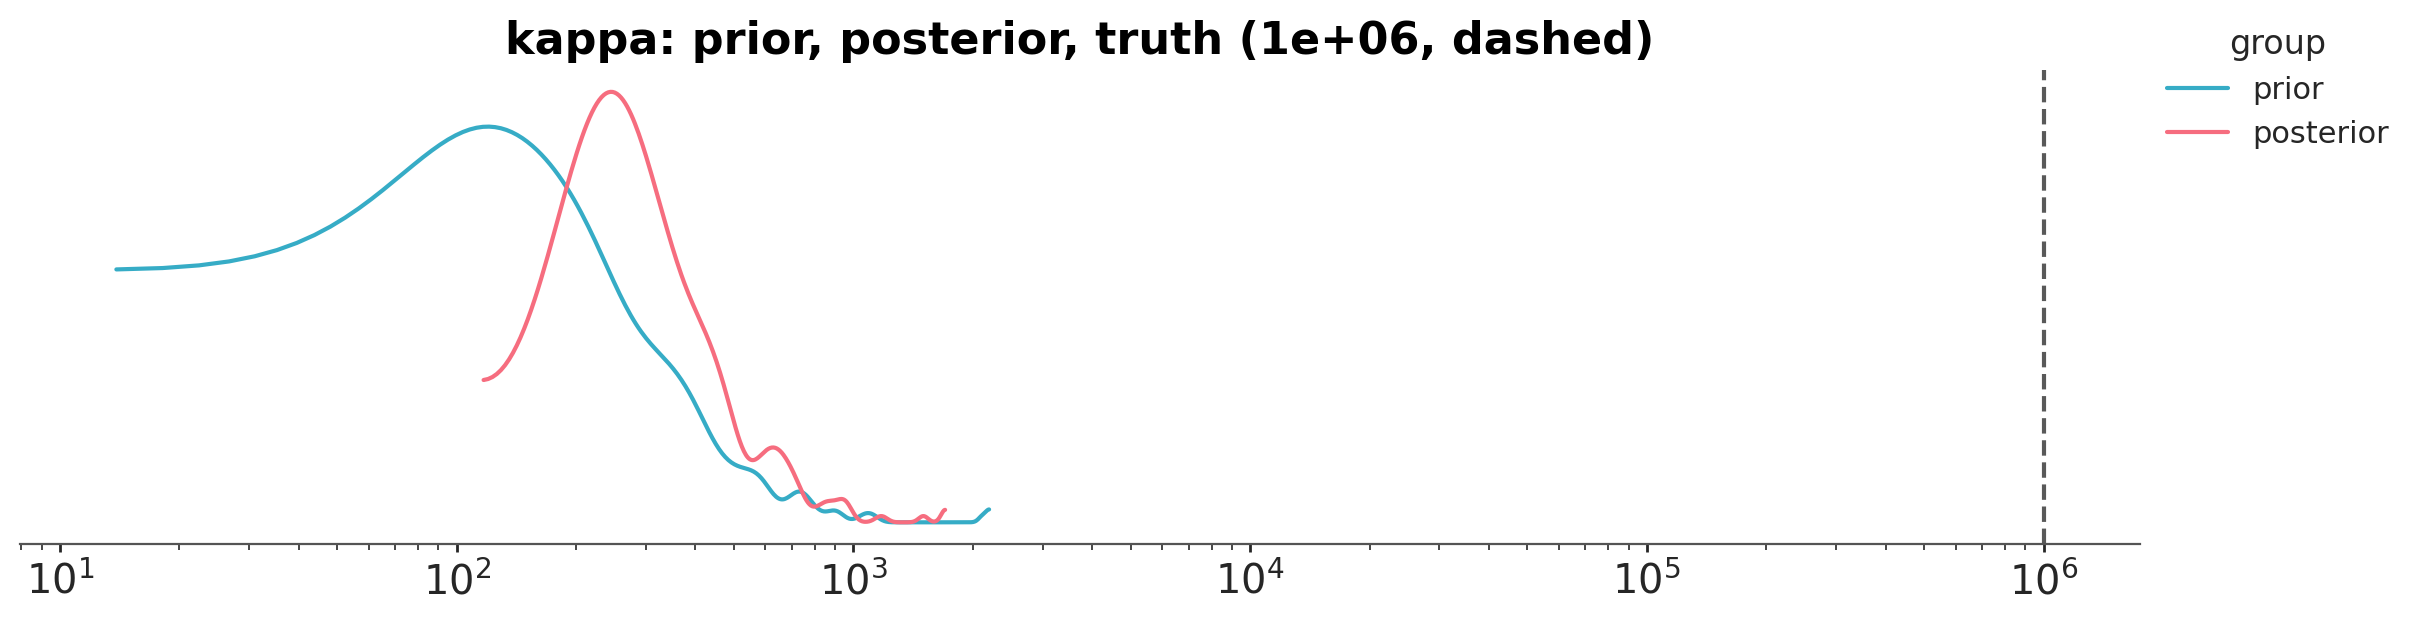

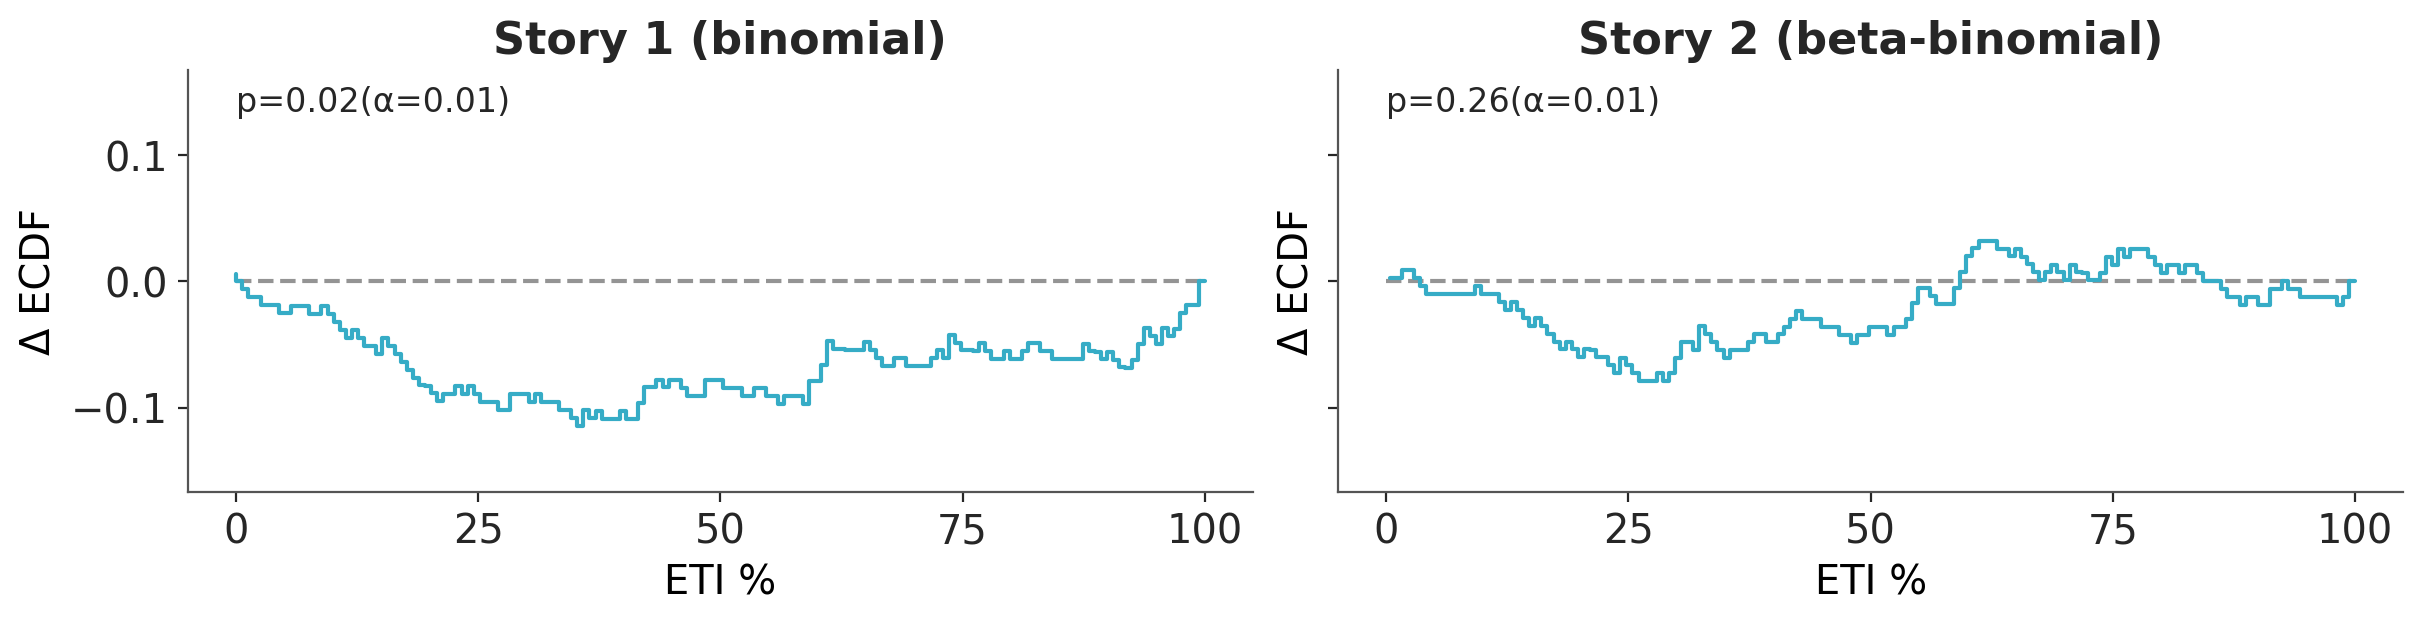

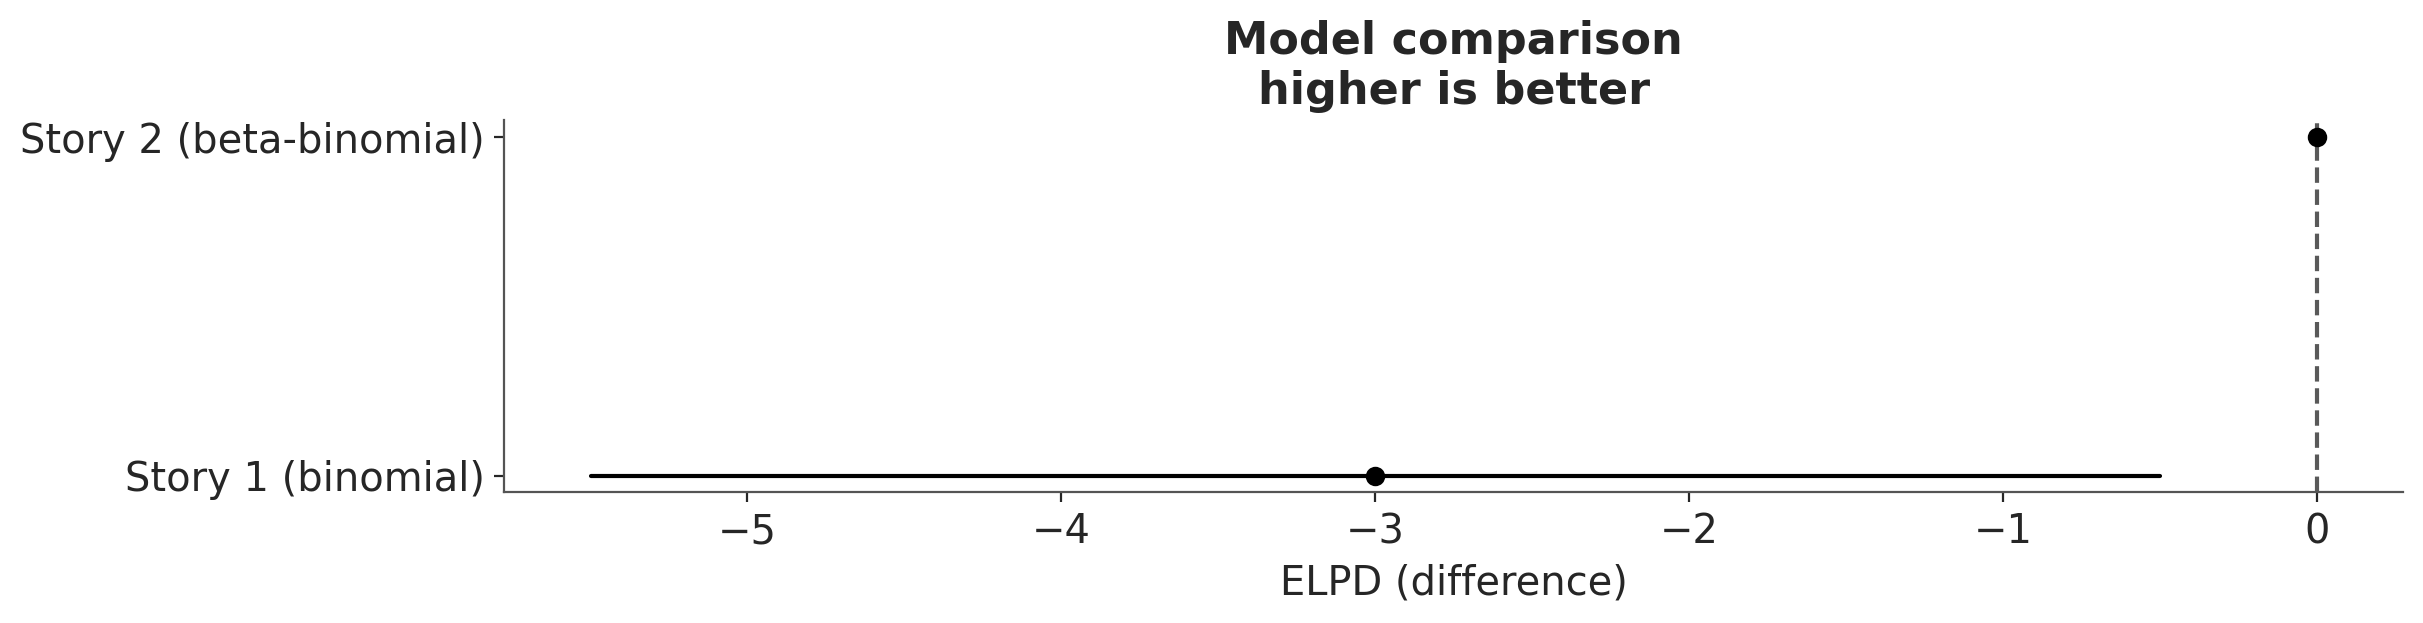

In [ ]:
### edit these, re-run the cell
KAPPA, N_TRIALS, N_SESSIONS = 1e6, 100, 4

sim_sessions, _, _, _ = simulate_sessions(
    n_participants=40, n_sessions=N_SESSIONS, n_trials=N_TRIALS, kappa=KAPPA, rng=rng
)
report(*sample_both(sim_sessions), sim_sessions, kappa_true=KAPPA)

## 12. The same data, handed to an AI assistant

Before today, I gave the exact data you just analysed to a coding assistant (Claude Code, on
Sonnet, but that's just for illustration, you can use whatever you want) with the kind of generic request most people would type:

> *"I ran a repeated-measures study: 40 participants did a task in two conditions across 5 sessions,
> 100 trials per session per condition. Can you (1) compute each participant's accuracy with a 95%
> interval, (2) test whether accuracy differs between the two conditions, and (3) write me a short
> report with a figure or two for lab meeting?"*

I ran it twice: once as-is, and once with an [open-source Bayesian workflow skill](https://github.com/Learning-Bayesian-Statistics/baygent-skills) I wrote. Read the [without-skill report](https://github.com/AlexAndorra/princeton-bayes-2026/blob/main/agent/runs/without-skill/report.md) and [with-skill report](https://github.com/AlexAndorra/princeton-bayes-2026/blob/main/agent/runs/with-skill/report.md), and **as you step through each run, check**:

- Did it ask, or say, what process generated the data (participants -> sessions -> trials)?
- Did it show what its model believed *before* seeing the data?
- Did it check that its method could recover something we know is true?
- Did its intervals keep their promise, and did it check?
- Did it stop at a single number (a p-value, a Bayes factor, an ELPD difference)?
- Did it tell you what it did *not* check?

Shout when you catch one (well, maybe not if you're reading that at a café or a library). Plot-level and question-level catches count; you don't need to read Python.

### What the skill changed

#### Without the skill

The assistant was careful: prior predictive check and prior sensitivity analysis (see "Model checks" in the [report](https://github.com/AlexAndorra/princeton-bayes-2026/blob/main/agent/runs/without-skill/report.md)), partial pooling and caveats (section 2 and "Caveats").

But look at the model block in section 2: `n_correct ~ Binomial(100, p)` with participant terms only, **nothing indexes the *session***. The agent even names that risk two sentences earlier... then does it.

It did check its predictions by eye, with an ECDF overlay ([`ppc_check.png`](https://github.com/AlexAndorra/princeton-bayes-2026/blob/main/agent/runs/without-skill/analysis/ppc_check.png)), but never their calibration.

#### With the skill

The assistant measured the overdispersion (see "How this was computed" in the [report](https://github.com/AlexAndorra/princeton-bayes-2026/blob/main/agent/runs/with-skill/report.md): sessions vary about 2.6x more than binomial noise allows; [`eda.py`](https://github.com/AlexAndorra/princeton-bayes-2026/blob/main/agent/runs/with-skill/eda.py)), ran the **PIT/coverage check** ([`pit_coverage.png`](https://github.com/AlexAndorra/princeton-bayes-2026/blob/main/agent/runs/with-skill/accuracy-hierarchical/pit_coverage.png), [`calibration.json`](https://github.com/AlexAndorra/princeton-bayes-2026/blob/main/agent/runs/with-skill/accuracy-hierarchical/calibration.json)) and LOO-CV ([`diagnostics.json`](https://github.com/AlexAndorra/princeton-bayes-2026/blob/main/agent/runs/with-skill/accuracy-hierarchical/diagnostics.json)), and reviewed its own work before finishing.

In fact, that review caught its first draft understating two failed diagnostics, so it rebuilt the model as the **beta-binomial** you just built! You can see these logs, with the before and after numbers, in [`review.md`](https://github.com/AlexAndorra/princeton-bayes-2026/blob/main/agent/runs/with-skill/review.md). And then, the agent built [`model.py`](https://github.com/AlexAndorra/princeton-bayes-2026/blob/main/agent/runs/with-skill/model.py), where it explained at the top why it chose the beta-binomial.

Much better scientific performance overall when using the skill -- which is, well, the whole point of the skill.


## Conclusion: the full workflow

1. **Write the story down**: participants from a population, sessions from participants, trials from sessions.
2. **Say what you believe before looking**, and simulate from it. If it looks absurd, fix it before sampling.
3. **Sample**, then check the *sampler* (R-hat, ESS, divergences). Necessary, never sufficient.
4. **Check the model against what you know**: on synthetic data, can it recover the truth?
5. **Simulate replications**: rootograms; coverage: "when it says 90%, is it right 90% of the time?".
6. **Expand where it fails**: a failed check is where the model gets better.
7. **Compare** with LOO-CV as *one* input among several; no magic-number-mentality.
8. **Use it**: predict, update, decide.

### Some references about the Bayesian workflow

- [Bayesian Workflow](https://learnbayesstats.com/episode/bayesian-workflow-reverse-bayes-hierarchical-pooling-gelman-vehtari-mcelreath), with **Andrew Gelman, Aki Vehtari & Richard McElreath**
- [A principled Bayesian workflow](https://learnbayesstats.com/episode/principled-bayesian-workflow-hamiltonian-monte-carlo-stan-michael-betancourt), with **Michael Betancourt**

Thank you so much for coming! Everything here is at [github.com/AlexAndorra/princeton-bayes-2026](https://github.com/AlexAndorra/princeton-bayes-2026),
and the podcast, where these ideas get argued about every two weeks, is [learnbayesstats.com](https://learnbayesstats.com).

Best Bayesian wishes 🖖